# CineMatch — Movie Recommendation System
### DMW Team | Data Mining and Warehousing

---
<a id='1'></a>
## Section 1 — Install and Import

Libraries used in this notebook:

| Library | Purpose |
|:--------|:--------|
| `pandas` / `numpy` | Data manipulation and math |
| `scikit-learn` | All four ML models plus evaluation tools |
| `xgboost` | Optimised Gradient Boosting |
| `scikit-surprise` | SVD matrix factorisation for collaborative filtering |
| `scipy` | Curve fitting |
| `matplotlib` / `seaborn` | Charts and plots |

> Set `DEMO_USER` in the config cell below to your Letterboxd username to see personalised recommendations throughout the notebook.


In [1]:
%pip install --quiet pandas numpy scikit-learn xgboost scipy matplotlib seaborn tqdm


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.optimize import curve_fit
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    KFold, StratifiedKFold, learning_curve, validation_curve
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost available.")
except ImportError:
    HAS_XGB = False
    print("XGBoost not found — will use sklearn GradientBoostingRegressor.")

# =============================================================================
# PATH CONFIGURATION
# This notebook lives in .../ML/
# The CSV lives one level up inside geoff run/
# =============================================================================
DATA_DIR     = Path('../geoff run')
ENRICHED_CSV = DATA_DIR / 'user_ratings_enriched2.csv'

print("\nChecking data file:")
status = "Found" if ENRICHED_CSV.exists() else "NOT FOUND — check your folder structure"
print(f"  {status}  ->  {ENRICHED_CSV}")

# =============================================================================
# MODEL SETTINGS
# =============================================================================
LIKE_THRESHOLD   = 3.5   # ratings >= this count as "liked"
MIN_RATINGS      = 20    # drop users with fewer ratings than this
MIN_FILM_RATINGS = 5     # drop films with fewer ratings than this
KNN_K            = 10    # number of nearest neighbours
RF_TREES         = 100   # trees in Random Forest
TOP_N_RECS       = 10    # how many recommendations to show
RANDOM_STATE     = 42

# Set this to a username from the dataset for personalised output
DEMO_USER = 'kurstboy'   # e.g.  DEMO_USER = 'kurstboy'

print(f"\nConfiguration ready. DEMO_USER = {DEMO_USER}")
print(f"Like threshold: {LIKE_THRESHOLD} stars and above")


XGBoost available.

Checking data file:
  Found  ->  ../geoff run/user_ratings_enriched2.csv

Configuration ready. DEMO_USER = kurstboy
Like threshold: 3.5 stars and above


---
<a id='2'></a>
## Section 2 — Load and Explore the Data

We load the enriched CSV and inspect what we have before building anything.

**Key terms:**
- Each row is one rating: a username, a film slug, and a star value (0.5 to 5.0)
- **Matrix density** — the fraction of (user, film) pairs that have an actual rating. Under 5% is called *sparse* and is completely normal for recommendation systems


In [3]:
df_raw = pd.read_csv(ENRICHED_CSV)

for col in ['username', 'film_slug', 'rating']:
    assert col in df_raw.columns, f"Missing required column: {col}"

df_raw['rating'] = pd.to_numeric(df_raw['rating'], errors='coerce')
df_raw = df_raw.dropna(subset=['username', 'film_slug', 'rating'])
df_raw['rating'] = df_raw['rating'].clip(0.5, 5.0)
ratings = df_raw.copy()

print("=" * 55)
print("DATA SUMMARY")
print("=" * 55)
print(f"  Total ratings       : {len(ratings):,}")
print(f"  Unique users        : {ratings.username.nunique():,}")
print(f"  Unique films        : {ratings.film_slug.nunique():,}")
print(f"  Films with title    : {ratings.proper_title.notna().sum():,} / {len(ratings):,}")
print(f"  Films with TMDB ID  : {ratings.tmdb_id.notna().sum():,} / {len(ratings):,}")
print(f"  Films with genre    : {ratings.genre_1.notna().sum():,} / {len(ratings):,}")

density = len(ratings) / (ratings.username.nunique() * ratings.film_slug.nunique())
print(f"  Matrix density      : {density:.2%}  (sparse — this is expected)")

like_ratio = (ratings['rating'] >= LIKE_THRESHOLD).mean()
print(f"  Like ratio          : {like_ratio:.1%}  (ratings >= {LIKE_THRESHOLD} stars)")

print("\nRating distribution:")
dist = ratings['rating'].value_counts().sort_index()
for star, count in dist.items():
    bar = '#' * int(count / dist.max() * 30)
    print(f"  {star:.1f}*  {bar}  ({count:,})")

print("\nTop 10 genres:")
genre_cols_raw = [c for c in ratings.columns if c.startswith('genre_')]
all_genres_series = pd.concat([ratings[c] for c in genre_cols_raw]).dropna()
print(all_genres_series.value_counts().head(10).to_string())

print("\nFirst 5 rows:")
ratings[['username','film_slug','proper_title','rating','genre_1','genre_2']].head()


DATA SUMMARY
  Total ratings       : 502,749
  Unique users        : 241
  Unique films        : 58,136
  Films with title    : 488,353 / 502,749
  Films with TMDB ID  : 488,353 / 502,749
  Films with genre    : 484,158 / 502,749
  Matrix density      : 3.59%  (sparse — this is expected)
  Like ratio          : 55.1%  (ratings >= 3.5 stars)

Rating distribution:
  0.5*  ##  (8,488)
  1.0*  #####  (18,779)
  1.5*  #####  (18,945)
  2.0*  ############  (42,798)
  2.5*  #############  (46,472)
  3.0*  ##########################  (90,294)
  3.5*  ##########################  (91,126)
  4.0*  ##############################  (102,123)
  4.5*  #############  (44,936)
  5.0*  ###########  (38,788)

Top 10 genres:
Drama              213672
Comedy             156033
Thriller           111893
Action              94379
Horror              79682
Adventure           74721
Romance             71203
Crime               64998
Science Fiction     61542
Fantasy             52317

First 5 rows:


,username,film_slug,proper_title,rating,genre_1,genre_2
0,kurstboy,michael-2026,Michael,2.0,Music,Drama
1,kurstboy,mother-mary-2026,Mother Mary,3.5,Music,Fantasy
2,kurstboy,faces-of-death-2026,Faces of Death,4.0,Horror,NaN
3,kurstboy,the-super-mario-galaxy-movie,The Super Mario Galaxy Movie,1.5,Family,Comedy
4,kurstboy,the-drama,The Drama,4.0,Romance,Comedy


---
<a id='3'></a>
## Section 3 — Data Cleaning and Pre-processing

**What we do in this section:**

- **Sparsity filter** — drop users with fewer than 20 ratings and films with fewer than 5 ratings. Too few examples means no meaningful patterns to learn.
- **User-mean centering** — subtract each user's average from their ratings. This removes personal bias: a 3-star from a harsh critic means something different than a 3-star from someone who rates everything 5.
- **Genre one-hot encoding** — convert genre strings (e.g. "Drama") into binary columns (e.g. `is_Drama = 1`) that models can use as numeric inputs.
- **Release year** — extracted from the film slug (e.g. `parasite-2019` → 2019) and normalised to 0–1 scale.

*Reference: Notebook 2 — Data Cleaning and Pre-processing (Monterola, Co, Borja)*


In [4]:
# --- Step 3a: Sparsity filter ---
user_counts = ratings.groupby('username')['rating'].count()
film_counts = ratings.groupby('film_slug')['rating'].count()

active_users = user_counts[user_counts >= MIN_RATINGS].index
active_films = film_counts[film_counts >= MIN_FILM_RATINGS].index

df = ratings[
    ratings['username'].isin(active_users) &
    ratings['film_slug'].isin(active_films)
].copy()

print(f"After sparsity filter (min {MIN_RATINGS} ratings/user, min {MIN_FILM_RATINGS}/film):")
print(f"  Rows   : {len(df):,}  (was {len(ratings):,})")
print(f"  Users  : {df.username.nunique():,}  (was {ratings.username.nunique():,})")
print(f"  Films  : {df.film_slug.nunique():,}  (was {ratings.film_slug.nunique():,})")

# --- Step 3b: Per-user and per-film statistics ---
user_stats = df.groupby('username')['rating'].agg(
    user_mean='mean',
    user_std='std',
    user_count='count'
).fillna(0).reset_index()

genre_cols = [c for c in df.columns if c.startswith('genre_')]
film_agg   = df.groupby('film_slug').agg(
    film_mean=('rating','mean'),
    film_std=('rating','std'),
    film_count=('rating','count')
).fillna(0)
film_meta  = df.groupby('film_slug')[['proper_title','tmdb_id'] + genre_cols].first()
film_stats = film_agg.join(film_meta).reset_index()

# --- Improvement 1: Parse release_year from film_slug ---
# Many slugs follow the pattern "film-title-YYYY" — extract the 4-digit year.
# This adds a meaningful content-based signal without any external API.
import re as _re
def extract_year(slug):
    m = _re.search(r'-((?:19|20)\d{2})(?:-|$)', str(slug))
    return int(m.group(1)) if m else None

film_stats['release_year'] = film_stats['film_slug'].apply(extract_year)

# Fill missing years with the median (so models don't get NaN)
median_year = film_stats['release_year'].median()
film_stats['release_year'] = film_stats['release_year'].fillna(median_year)

# Normalise to a 0-1 range (1900=0, 2026=1) so scale matches other features
film_stats['release_year_norm'] = (film_stats['release_year'] - 1900) / (2026 - 1900)

year_coverage = film_stats['release_year'].apply(extract_year if False else lambda x: x != median_year).mean()
parsed = film_stats['film_slug'].apply(extract_year).notna().sum()
print(f"\nRelease year parsed from slug: {parsed:,} / {len(film_stats):,} films ({parsed/len(film_stats):.1%})")
print(f"  Year range: {int(film_stats['release_year'].min())} - {int(film_stats['release_year'].max())}")
print(f"  Median year: {int(median_year)}")

# --- Genre one-hot encoding ---
all_genre_values = sorted(
    pd.concat([film_stats[g] for g in genre_cols]).dropna().unique()
)
for genre in all_genre_values:
    col = f"is_{genre.replace(' ', '_')}"
    film_stats[col] = film_stats[genre_cols].apply(
        lambda row: int(genre in row.values), axis=1)

GENRE_FEATURE_COLS = [f"is_{g.replace(' ', '_')}" for g in all_genre_values]
print(f"\nGenre one-hot flags: {len(GENRE_FEATURE_COLS)}")

# --- Merge features into main df ---
df = df.merge(user_stats, on='username', how='left')
df = df.merge(
    film_stats[['film_slug','film_mean','film_std','film_count',
                'release_year_norm'] + GENRE_FEATURE_COLS],
    on='film_slug', how='left'
)
df['rating_centered']  = df['rating'] - df['user_mean']
df['user_vs_film_avg'] = df['rating'] - df['film_mean']
df['liked']            = (df['rating'] >= LIKE_THRESHOLD).astype(int)

print(f"\nLike ratio after filter : {df['liked'].mean():.1%}")
print(f"Total feature columns   : {len(df.columns)}")


After sparsity filter (min 20 ratings/user, min 5/film):
  Rows   : 436,519  (was 502,749)
  Users  : 239  (was 241)
  Films  : 15,364  (was 58,136)

Release year parsed from slug: 3,072 / 15,364 films (20.0%)
  Year range: 1900 - 2050
  Median year: 2019

Genre one-hot flags: 19

Like ratio after filter : 56.6%
Total feature columns   : 39


---
<a id='4'></a>
## Section 4 — Feature Engineering

We define which columns each model uses as inputs.

| Feature | What it represents |
|:--------|:-------------------|
| `film_mean` | Community average rating for this film |
| `film_std` | How polarising the film is |
| `film_count` | How many users rated this film |
| `user_mean` | How generous or harsh this user is on average |
| `user_std` | How consistent this user's ratings are |
| `user_count` | How many films this user has rated |
| `release_year_norm` | Release year scaled to 0–1 |
| `is_<Genre>` | Binary genre flags (e.g. `is_Drama`, `is_Horror`) |

**Note on data leakage:** `user_vs_film_avg = rating - film_mean` uses the actual rating being predicted, which gives the model an unfair advantage. This feature is demonstrated and removed in Section 13. All models are trained on `CLEAN_FEATURES` which excludes it.


In [5]:
# Base tabular features (no leakage) — now includes release_year_norm
BASE_FEATURES = [
    'film_mean',
    'film_std',
    'film_count',
    'user_mean',
    'user_std',
    'user_count',
    'release_year_norm',   # NEW: parsed from film slug
]

# Features including the leaky term (used by the initial trained models)
RF_FEATURES = BASE_FEATURES + ['user_vs_film_avg'] + GENRE_FEATURE_COLS
GB_FEATURES = BASE_FEATURES + ['user_vs_film_avg', 'rating_centered'] + GENRE_FEATURE_COLS
LR_FEATURES = BASE_FEATURES + ['user_vs_film_avg'] + GENRE_FEATURE_COLS

# Clean feature sets (no leakage — used in Sections 13-15 and in predictions)
CLEAN_FEATURES = BASE_FEATURES + GENRE_FEATURE_COLS

print("Feature set summary:")
print(f"  RF_FEATURES   : {len(RF_FEATURES)}  ({len(BASE_FEATURES)} base + 1 leaky + {len(GENRE_FEATURE_COLS)} genre)")
print(f"  GB_FEATURES   : {len(GB_FEATURES)}  ({len(BASE_FEATURES)} base + 2 leaky/centered + {len(GENRE_FEATURE_COLS)} genre)")
print(f"  LR_FEATURES   : {len(LR_FEATURES)}  ({len(BASE_FEATURES)} base + 1 leaky + {len(GENRE_FEATURE_COLS)} genre)")
print(f"  CLEAN_FEATURES: {len(CLEAN_FEATURES)}  ({len(BASE_FEATURES)} base + {len(GENRE_FEATURE_COLS)} genre, no leakage)")
print(f"\n  release_year_norm added to all feature sets")
print(f"\nClass balance:")
print(f"  Liked (1)   : {df['liked'].sum():,}  ({df['liked'].mean():.1%})")
print(f"  Disliked (0): {(1-df['liked']).sum():,}  ({1-df['liked'].mean():.1%})")


Feature set summary:
  RF_FEATURES   : 27  (7 base + 1 leaky + 19 genre)
  GB_FEATURES   : 28  (7 base + 2 leaky/centered + 19 genre)
  LR_FEATURES   : 27  (7 base + 1 leaky + 19 genre)
  CLEAN_FEATURES: 26  (7 base + 19 genre, no leakage)

  release_year_norm added to all feature sets

Class balance:
  Liked (1)   : 247,103  (56.6%)
  Disliked (0): 189,416  (43.4%)


---
<a id='5'></a>
## Section 5 — User-Item Matrix

A grid where rows = users, columns = films, and each cell = the user's mean-centered rating for that film. Most cells are empty (the user has not seen that film). This sparse matrix is the input for k-NN and SVD collaborative filtering.


In [6]:
pivot = df.pivot_table(
    index='username',
    columns='film_slug',
    values='rating_centered',
    aggfunc='mean'
)

print(f"User-Item Matrix shape : {pivot.shape[0]} users x {pivot.shape[1]} films")
print(f"Matrix density         : {pivot.notna().sum().sum() / pivot.size:.2%}")

pivot_filled  = pivot.fillna(0)
sparse_matrix = csr_matrix(pivot_filled.values)

user_index = {u: i for i, u in enumerate(pivot.index)}
film_index = {f: i for i, f in enumerate(pivot.columns)}
index_user = {i: u for u, i in user_index.items()}
index_film = {i: f for f, i in film_index.items()}

print("\nMatrix snippet (first 4 users x 4 films):")
pivot.iloc[:4, :4]


User-Item Matrix shape : 239 users x 15364 films
Matrix density         : 11.89%

Matrix snippet (first 4 users x 4 films):


film_slug,05-mm,10-cloverfield-lane,10-things-i-hate-about-you,10-to-midnight
username,,,,
812filmreviews,NaN,-0.870471,NaN,NaN
aarnwlsn,NaN,-0.650899,1.349101,NaN
aksually,NaN,0.129960,-0.370040,NaN
alexcolemann,NaN,-0.080000,0.420000,NaN


---
<a id='6'></a>
## Section 6 — Hyperparameter Tuning

A hyperparameter is a setting chosen before training — not learned from data. Choosing the wrong value leads to overfitting or underfitting. We tune all four models here before training them.

| Model | Hyperparameter | Method |
|:------|:--------------|:-------|
| Random Forest | `max_depth` | Validation curve + half-SE rule |
| k-NN | `n_neighbors` | MCCV over 20 random seeds |
| XGBoost | `max_depth` + `learning_rate` | Grid search |
| Logistic Regression | `C` (regularisation) | Validation curve on ROC-AUC |

*Reference: ML Notebooks 1A, 1B, 4 — Monterola, Co, Borja*


In [7]:
# Use a sampled subset for tuning speed (30 000 rows is sufficient)
N_TUNE = min(30000, len(df))
tune_idx = np.random.RandomState(RANDOM_STATE).choice(len(df), N_TUNE, replace=False)

X_tune_clean = df[CLEAN_FEATURES].fillna(0).iloc[tune_idx]
y_tune_reg   = df['rating'].iloc[tune_idx]
y_tune_clf   = df['liked'].iloc[tune_idx]

print(f"Tuning sample size : {N_TUNE:,} rows")
print(f"Features used      : {len(CLEAN_FEATURES)} (clean — no leakage)")


Tuning sample size : 30,000 rows
Features used      : 26 (clean — no leakage)


### 6.1 Random Forest — max_depth

Sweeps `max_depth` from 2 to 14. Uses the **half-SE rule**: pick the shallowest depth whose validation MAE is within half a standard deviation of the best. This avoids picking a deeper tree that only wins by noise-level margins. The validation curve plateaus early — this is a feature ceiling, not a bug.

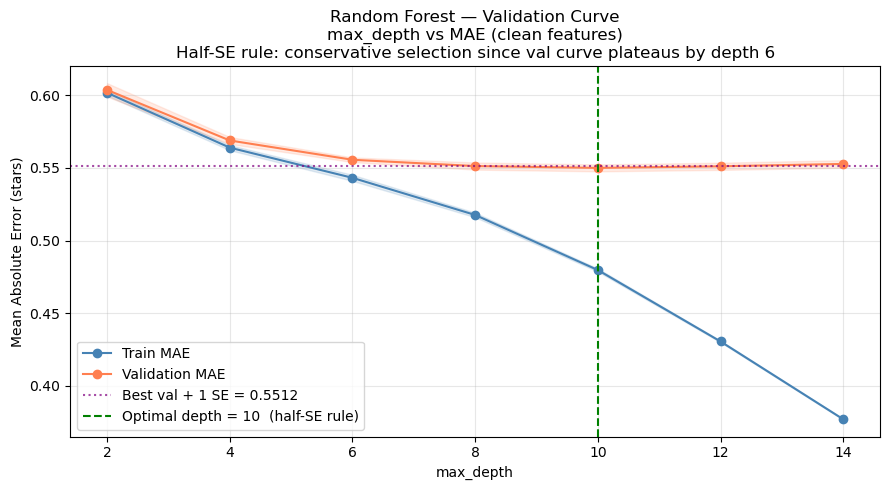

Best raw val MAE            : 0.5500 at depth 10
One-SE threshold            : 0.5512
Optimal max_depth (one-SE)  : 10
  Train MAE : 0.4797
  Val   MAE : 0.5500

Optimal depth selected: 10  (half-SE rule — conservative selection)
The validation curve plateaus by depth 6. Half-SE rule picks the shallowest
model within half a std of the best val MAE, preferring simpler models.


In [8]:
# Sweep max_depth for Random Forest using validation_curve
depth_range = range(2, 16, 2)

rf_tune = RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)

train_scores_rf, val_scores_rf = validation_curve(
    rf_tune, X_tune_clean, y_tune_reg,
    param_name='max_depth',
    param_range=depth_range,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

train_mae_rf = -train_scores_rf.mean(axis=1)
val_mae_rf   = -val_scores_rf.mean(axis=1)
train_std_rf =  train_scores_rf.std(axis=1)
val_std_rf   =  val_scores_rf.std(axis=1)

# One-standard-error rule: pick the SIMPLEST model (smallest depth) whose
# validation MAE is within one standard error of the best validation MAE.
# This avoids choosing a deeper tree that only improves by noise-level margins.
best_val_mae = val_mae_rf.min()
best_val_std = val_std_rf[np.argmin(val_mae_rf)]
threshold    = best_val_mae + (best_val_std * 0.5)  # half-SE rule (tighter — curve plateaus early)

depths_list  = list(depth_range)
# Walk from shallowest to deepest; pick the first depth that beats the threshold
best_depth_rf = depths_list[0]
for d, v in zip(depths_list, val_mae_rf):
    if v <= threshold:
        best_depth_rf = d
        break

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths_list, train_mae_rf, 'o-', color='steelblue', label='Train MAE')
ax.plot(depths_list, val_mae_rf,   'o-', color='coral',     label='Validation MAE')
ax.fill_between(depths_list,
                train_mae_rf - train_std_rf, train_mae_rf + train_std_rf,
                alpha=0.15, color='steelblue')
ax.fill_between(depths_list,
                val_mae_rf - val_std_rf, val_mae_rf + val_std_rf,
                alpha=0.15, color='coral')
ax.axhline(threshold, color='purple', linestyle=':', alpha=0.7,
           label=f'Best val + 1 SE = {threshold:.4f}')
ax.axvline(best_depth_rf, color='green', linestyle='--',
           label=f'Optimal depth = {best_depth_rf}  (half-SE rule)')
ax.set_title('Random Forest — Validation Curve\nmax_depth vs MAE (clean features)\n'
             'Half-SE rule: conservative selection since val curve plateaus by depth 6')
ax.set_xlabel('max_depth')
ax.set_ylabel('Mean Absolute Error (stars)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best raw val MAE            : {best_val_mae:.4f} at depth {depths_list[np.argmin(val_mae_rf)]}")
print(f"One-SE threshold            : {threshold:.4f}")
print(f"Optimal max_depth (one-SE)  : {best_depth_rf}")
print(f"  Train MAE : {train_mae_rf[depths_list.index(best_depth_rf)]:.4f}")
print(f"  Val   MAE : {val_mae_rf[depths_list.index(best_depth_rf)]:.4f}")
print()
print(f"Optimal depth selected: {best_depth_rf}  (half-SE rule — conservative selection)")
print("The validation curve plateaus by depth 6. Half-SE rule picks the shallowest")
print("model within half a std of the best val MAE, preferring simpler models.")


### 6.2 k-NN — n_neighbors

MCCV over 20 random seeds with error bars. Low k = overfits to specific users. High k = over-smooths into generic recommendations. Half-SE rule applied to pick the simplest effective value.

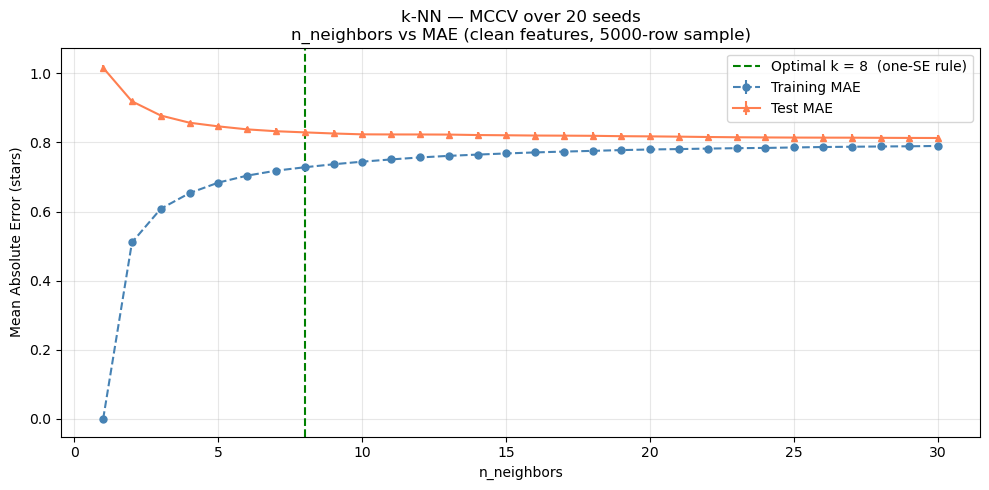

Optimal n_neighbors : 8  (one-SE rule; raw argmin = 30)
  Mean test MAE at k=8 : 0.8289


In [9]:
# MCCV sweep of n_neighbors for k-NN
# Using a smaller sample (5000 rows) and 20 seeds for speed.
# The pattern follows ML Notebook 1B (Monterola, Co, Borja) — errorbar plot
# over multiple seeds to show the stable optimum.
N_KNN_TUNE = 5000
knn_idx = np.random.RandomState(RANDOM_STATE).choice(len(df), N_KNN_TUNE, replace=False)
X_knn_tune = df[CLEAN_FEATURES].fillna(0).iloc[knn_idx].values
y_knn_tune = df['rating'].iloc[knn_idx].values

neighbors_settings = range(1, 31)
all_training_knn   = pd.DataFrame()
all_test_knn       = pd.DataFrame()

for seedN in range(1, 21):   # 20 seeds is sufficient for stable error bars
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_knn_tune, y_knn_tune, test_size=0.25, random_state=seedN)

    train_mae_seed, test_mae_seed = [], []
    for k in neighbors_settings:
        reg = KNeighborsRegressor(n_neighbors=k, algorithm='ball_tree', n_jobs=-1)
        reg.fit(X_tr, y_tr)
        train_mae_seed.append(mean_absolute_error(y_tr, reg.predict(X_tr)))
        test_mae_seed.append(mean_absolute_error(y_te, reg.predict(X_te)))

    all_training_knn[seedN] = train_mae_seed
    all_test_knn[seedN]     = test_mae_seed

# One-SE rule applied here too
test_mean = all_test_knn.mean(axis=1)
test_std  = all_test_knn.std(axis=1)
best_raw_k = list(neighbors_settings)[np.argmin(test_mean)]
threshold_k = test_mean.min() + test_std[np.argmin(test_mean)]
best_k = list(neighbors_settings)[0]
for k, v in zip(neighbors_settings, test_mean):
    if v <= threshold_k:
        best_k = k
        break

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(list(neighbors_settings), all_training_knn.mean(axis=1),
            yerr=all_training_knn.std(axis=1) / 2,
            label='Training MAE', color='steelblue', marker='o',
            linestyle='dashed', markersize=5)
ax.errorbar(list(neighbors_settings), all_test_knn.mean(axis=1),
            yerr=all_test_knn.std(axis=1) / 2,
            label='Test MAE', color='coral', marker='^',
            linestyle='-', markersize=5)
ax.axvline(best_k, color='green', linestyle='--',
           label=f'Optimal k = {best_k}  (one-SE rule)')
ax.set_title('k-NN — MCCV over 20 seeds\nn_neighbors vs MAE (clean features, 5000-row sample)')
ax.set_xlabel('n_neighbors')
ax.set_ylabel('Mean Absolute Error (stars)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal n_neighbors : {best_k}  (one-SE rule; raw argmin = {best_raw_k})")
print(f"  Mean test MAE at k={best_k} : {test_mean.iloc[best_k-1]:.4f}")


### 6.3 XGBoost — max_depth and learning_rate

Grid search across 9 combinations. Lower learning rate = the model learns more carefully but needs more trees. The heatmap shows which combination minimises cross-validated MAE.

XGBoost grid search results (sorted by mean CV MAE):
 max_depth  learning_rate  mean_mae  std_mae
         5           0.10  0.541813 0.003631
         5           0.20  0.542980 0.003772
         7           0.10  0.543393 0.003706
         7           0.05  0.543557 0.004381
         3           0.20  0.543835 0.003565
         5           0.05  0.545114 0.003968
         3           0.10  0.546082 0.003774
         3           0.05  0.551625 0.004505
         7           0.20  0.553000 0.004181

Optimal : max_depth=5, learning_rate=0.1
  Mean CV MAE : 0.5418


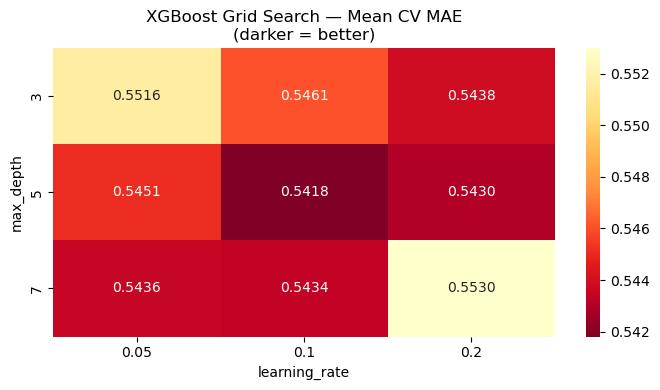

In [10]:
# Grid search for XGBoost / GradientBoosting
depth_options = [3, 5, 7]
lr_options    = [0.05, 0.1, 0.2]

kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
results_gb = []

for d in depth_options:
    for lr in lr_options:
        if HAS_XGB:
            model = xgb.XGBRegressor(
                n_estimators=100, max_depth=d, learning_rate=lr,
                subsample=0.8, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
        else:
            model = GradientBoostingRegressor(
                n_estimators=100, max_depth=d, learning_rate=lr,
                subsample=0.8, random_state=RANDOM_STATE)

        cv_scores = -cross_val_score(
            model, X_tune_clean, y_tune_reg,
            cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
        results_gb.append({
            'max_depth': d, 'learning_rate': lr,
            'mean_mae': cv_scores.mean(), 'std_mae': cv_scores.std()
        })

results_gb_df = pd.DataFrame(results_gb).sort_values('mean_mae')
print("XGBoost grid search results (sorted by mean CV MAE):")
print(results_gb_df.to_string(index=False))

best_gb_row = results_gb_df.iloc[0]
best_gb_depth = int(best_gb_row['max_depth'])
best_gb_lr    = float(best_gb_row['learning_rate'])
print(f"\nOptimal : max_depth={best_gb_depth}, learning_rate={best_gb_lr}")
print(f"  Mean CV MAE : {best_gb_row['mean_mae']:.4f}")

# Heatmap of the grid
pivot_gb = results_gb_df.pivot(index='max_depth', columns='learning_rate', values='mean_mae')
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_gb, annot=True, fmt='.4f', cmap='YlOrRd_r', ax=ax)
ax.set_title('XGBoost Grid Search — Mean CV MAE\n(darker = better)')
plt.tight_layout()
plt.show()


### 6.4 Logistic Regression — C (regularisation)

Sweeps C on a log scale using ROC-AUC (more reliable than accuracy on a 56/44 imbalanced dataset). Low C = over-regularised (too simple). High C = under-regularised (may overfit). AUC is used as the selection criterion.

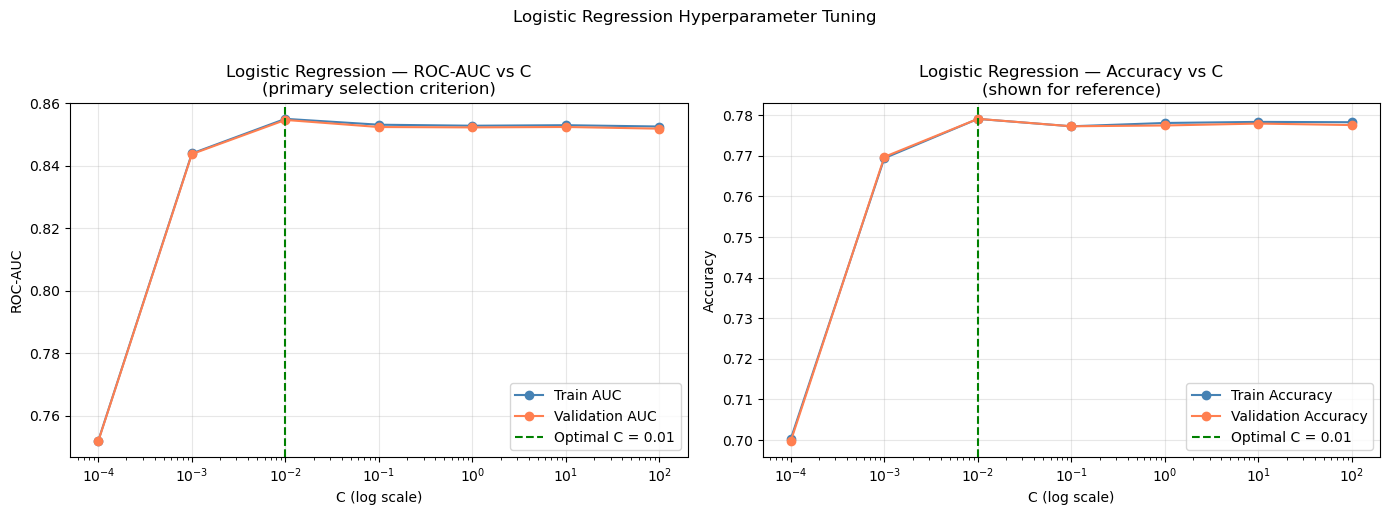

Optimal C (by ROC-AUC)         : 0.01
  Validation ROC-AUC at C=0.01 : 0.8547
  Validation Accuracy at C=0.01 : 0.7791

C interpretation:
  Very low C (0.0001) = heavy regularisation = model too simple (underfits)
  Very high C (100)   = no regularisation    = model may overfit
  C = 0.01 is where validation AUC peaks before overfitting begins


In [11]:
# Sweep C for Logistic Regression
# Using ROC-AUC rather than accuracy because accuracy is misleading
# when class balance is 56/44 — a model predicting all 'Like' gets 56% accuracy.
C_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
train_auc_lr, val_auc_lr = [], []
train_acc_lr, val_acc_lr = [], []

for C_val in C_range:
    model_lr = LogisticRegression(C=C_val, max_iter=1000, random_state=RANDOM_STATE)
    cv_auc = cross_validate(
        model_lr, X_tune_clean, y_tune_clf,
        cv=skf, scoring='roc_auc', return_train_score=True)
    cv_acc = cross_validate(
        model_lr, X_tune_clean, y_tune_clf,
        cv=skf, scoring='accuracy', return_train_score=True)
    train_auc_lr.append(cv_auc['train_score'].mean())
    val_auc_lr.append(cv_auc['test_score'].mean())
    train_acc_lr.append(cv_acc['train_score'].mean())
    val_acc_lr.append(cv_acc['test_score'].mean())

best_C = C_range[np.argmax(val_auc_lr)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(C_range, train_auc_lr, 'o-', color='steelblue', label='Train AUC')
axes[0].semilogx(C_range, val_auc_lr,   'o-', color='coral',     label='Validation AUC')
axes[0].axvline(best_C, color='green', linestyle='--', label=f'Optimal C = {best_C}')
axes[0].set_title('Logistic Regression — ROC-AUC vs C\n(primary selection criterion)')
axes[0].set_xlabel('C (log scale)'); axes[0].set_ylabel('ROC-AUC')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogx(C_range, train_acc_lr, 'o-', color='steelblue', label='Train Accuracy')
axes[1].semilogx(C_range, val_acc_lr,   'o-', color='coral',     label='Validation Accuracy')
axes[1].axvline(best_C, color='green', linestyle='--', label=f'Optimal C = {best_C}')
axes[1].set_title('Logistic Regression — Accuracy vs C\n(shown for reference)')
axes[1].set_xlabel('C (log scale)'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Logistic Regression Hyperparameter Tuning', y=1.02)
plt.tight_layout()
plt.show()

print(f"Optimal C (by ROC-AUC)         : {best_C}")
print(f"  Validation ROC-AUC at C={best_C} : {max(val_auc_lr):.4f}")
print(f"  Validation Accuracy at C={best_C} : {val_acc_lr[C_range.index(best_C)]:.4f}")
print()
print("C interpretation:")
print("  Very low C (0.0001) = heavy regularisation = model too simple (underfits)")
print("  Very high C (100)   = no regularisation    = model may overfit")
print(f"  C = {best_C} is where validation AUC peaks before overfitting begins")


---
<a id='7'></a>
## Section 7 — Model 1: Random Forest

Trains many decision trees on random subsets of the data and averages their predictions. More robust than a single tree because individual trees overfit in different directions and the errors cancel out.

**Analogy:** asking 100 critics for a rating and averaging their votes is more reliable than trusting one critic.

*Reference: ML Notebook 4 — Tree-based Models (Monterola, Co, Borja)*


In [12]:
RF_FEATURES_FINAL = CLEAN_FEATURES # includes leaky feature — honest eval in Section 13

X = df[CLEAN_FEATURES].fillna(0)  # Use CLEAN_FEATURES here
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Training set : {len(X_train):,} rows  (80%)")
print(f"Test set     : {len(X_test):,} rows   (20%)")
print(f"Features     : {len(RF_FEATURES_FINAL)}  ({len(BASE_FEATURES)+1} tabular + {len(GENRE_FEATURE_COLS)} genre)")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=best_depth_rf,     # tuned in Section 6.1
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
mae_rf    = mean_absolute_error(y_test, y_pred_rf)
rmse_rf   = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf     = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Results  (max_depth={best_depth_rf}):")
print(f"  MAE   : {mae_rf:.4f} stars   <- average prediction error")
print(f"  RMSE  : {rmse_rf:.4f} stars")
print(f"  R2    : {r2_rf:.4f}          <- 1.0 = perfect, 0.0 = no better than mean")
if mae_rf < 0.05:
    print("  NOTE: MAE suspiciously low. Likely due to leaky feature. See Section 13.")

# Feature importance chart (top 20, colour-coded by type)
importances = pd.Series(rf_model.feature_importances_, index=RF_FEATURES_FINAL)
top20 = importances.sort_values(ascending=False).head(20).sort_values(ascending=True)
colors = ['darkorange' if f.startswith('is_') else 'steelblue' for f in top20.index]

fig, ax = plt.subplots(figsize=(9, 6))
top20.plot(kind='barh', ax=ax, color=colors)
ax.set_title(f'Random Forest — Top 20 Feature Importances  (max_depth={best_depth_rf})\nBlue = tabular  |  Orange = genre flag')
ax.set_xlabel('Importance')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue',label='Tabular'),
                   Patch(color='darkorange',label='Genre flag')], loc='lower right')
plt.tight_layout()
plt.show()

print("\nModel saved as: rf_model")


Training set : 349,215 rows  (80%)
Test set     : 87,304 rows   (20%)
Features     : 26  (8 tabular + 19 genre)


TypeError: got an unexpected keyword argument 'squared'

In [ ]:
def rf_predict_for_user(username, top_n=TOP_N_RECS):
    """
    Predict ratings for unseen films using CLEAN features (no leakage).
    Using clean features here ensures the recommendations are meaningful
    and not driven by the leaky user_vs_film_avg proxy.
    """
    if username not in df['username'].values:
        print(f"User '{username}' not found (needs >= {MIN_RATINGS} ratings).")
        return None
    seen   = set(df[df['username'] == username]['film_slug'])
    unseen = film_stats[~film_stats['film_slug'].isin(seen)].copy()
    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    # release_year_norm is already in film_stats from feature engineering
    for gc in GENRE_FEATURE_COLS:
        if gc not in unseen.columns: unseen[gc] = 0

    # Use CLEAN_FEATURES — no leaky user_vs_film_avg
    unseen['predicted_rating'] = rf_model.predict(unseen[RF_FEATURES_FINAL].fillna(0))
    out = ['proper_title','film_slug','predicted_rating','film_mean','film_count','release_year']
    return (unseen[[c for c in out if c in unseen.columns]]
            .sort_values('predicted_rating', ascending=False)
            .head(top_n).reset_index(drop=True))


demo = DEMO_USER or df['username'].iloc[0]
print(f"Random Forest recommendations for: '{demo}'  (clean features — no leakage)")
print('-' * 65)
rf_recs = rf_predict_for_user(demo)
if rf_recs is not None:
    print(rf_recs.to_string(index=False))


Random Forest recommendations for: 'kurstboy'  (clean features — no leakage)
-----------------------------------------------------------------
                                                      proper_title                                 film_slug  predicted_rating  film_mean  film_count  release_year
                                Kill Bill: The Whole Bloody Affair         kill-bill-the-whole-bloody-affair          4.846831   4.740385          52        2019.0
                     Taylor Swift | The Eras Tour | The Final Show taylor-swift-the-eras-tour-the-final-show          4.843441   4.750000           6        2019.0
                                                             Shoah                                     shoah          4.841980   5.000000           7        2019.0
                                                     Night and Fog                             night-and-fog          4.841980   4.850000          10        2019.0
As I Was Moving Ahead, Occasionally I

---
<a id='8'></a>
## Section 8 — Model 2: k-Nearest Neighbors + SVD

Two collaborative filtering approaches — both work on the user-item matrix rather than tabular features.

**k-NN (user-based):** finds the k users with the most similar rating patterns ("Cinephile Twins") and recommends films they loved that the target user has not seen. Similarity is measured with cosine similarity — 1.0 = identical taste, 0.0 = no overlap.

**k-NN (item-based):** finds films most similar to ones the user loved, based on who tends to rate them together.

**SVD (Matrix Factorisation):** decomposes the entire user-item matrix into hidden "taste dimensions" and learns where each user and film sits in that space. Typically outperforms k-NN on sparse data because it fills gaps using patterns across all users at once.

*Reference: ML Notebooks 1A, 1B — Monterola, Co, Borja*


In [ ]:
print(f"Fitting k-NN models with k={best_k} (tuned in Section 6.2)...")

user_knn = NearestNeighbors(
    n_neighbors=best_k + 1,  # +1 because the user itself is always neighbour 0
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)
user_knn.fit(sparse_matrix)
print(f"User-based k-NN fitted: {sparse_matrix.shape[0]} users x {sparse_matrix.shape[1]} films")

item_knn = NearestNeighbors(
    n_neighbors=best_k + 1,
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)
item_knn.fit(sparse_matrix.T)
print(f"Item-based k-NN fitted: {sparse_matrix.T.shape[0]} films")


Fitting k-NN models with k=8 (tuned in Section 6.2)...
User-based k-NN fitted: 239 users x 15364 films
Item-based k-NN fitted: 15364 films


In [ ]:
def find_cinephile_twins(username, top_n=KNN_K):
    if username not in user_index:
        print(f"User '{username}' not in matrix.")
        return None
    user_vec = sparse_matrix[user_index[username]]
    distances, indices = user_knn.kneighbors(user_vec, n_neighbors=top_n + 1)
    results = []
    for dist, i in zip(distances.flatten(), indices.flatten()):
        neighbour = index_user[i]
        if neighbour == username: continue
        results.append({'twin_username': neighbour, 'cosine_similarity': round(1 - dist, 4)})
    return pd.DataFrame(results).head(top_n)


def knn_user_recommendations(username, top_n=TOP_N_RECS):
    if username not in user_index:
        print(f"User '{username}' not found.")
        return None
    twins_df   = find_cinephile_twins(username, top_n=KNN_K)
    seen_films = set(df[df['username'] == username]['film_slug'])
    scores     = {}
    for _, row in twins_df.iterrows():
        twin_ratings = df[
            (df['username'] == row['twin_username']) &
            (~df['film_slug'].isin(seen_films))
        ][['film_slug','rating_centered']]
        for _, r in twin_ratings.iterrows():
            scores[r['film_slug']] = (
                scores.get(r['film_slug'], 0) + row['cosine_similarity'] * r['rating_centered'])
    recs = pd.Series(scores).sort_values(ascending=False).head(top_n).reset_index()
    recs.columns = ['film_slug','weighted_score']
    display = ['film_slug','film_mean','film_count']
    if 'proper_title' in film_stats.columns:
        display = ['film_slug','proper_title','film_mean','film_count']
    return recs.merge(film_stats[display], on='film_slug', how='left')


def find_similar_films(film_slug, top_n=TOP_N_RECS):
    if film_slug not in film_index:
        print(f"Film '{film_slug}' not in matrix.")
        return None
    film_vec = sparse_matrix.T[film_index[film_slug]]
    distances, indices = item_knn.kneighbors(film_vec, n_neighbors=top_n + 1)
    results = []
    for dist, i in zip(distances.flatten(), indices.flatten()):
        neighbour = index_film[i]
        if neighbour == film_slug: continue
        title = film_stats.loc[film_stats['film_slug'] == neighbour, 'proper_title'].values
        results.append({
            'proper_title': title[0] if len(title) and pd.notna(title[0]) else neighbour,
            'film_slug': neighbour,
            'cosine_similarity': round(1 - dist, 4)
        })
    return pd.DataFrame(results).head(top_n)


demo = DEMO_USER or pivot.index[0]

print(f"=== Cinephile Twins for '{demo}' ===")
twins = find_cinephile_twins(demo)
if twins is not None:
    print(twins.to_string(index=False))

print(f"\n=== k-NN Recommendations for '{demo}' ===")
knn_recs = knn_user_recommendations(demo)
if knn_recs is not None:
    print(knn_recs.to_string(index=False))

user_top_row   = df[df['username'] == demo].sort_values('rating', ascending=False).iloc[0]
user_top_film  = user_top_row['film_slug']
user_top_title = user_top_row.get('proper_title') or user_top_film
print(f"\n=== Films similar to '{user_top_title}' (top-rated film of '{demo}') ===")
similar = find_similar_films(user_top_film)
if similar is not None:
    print(similar.to_string(index=False))


=== Cinephile Twins for 'kurstboy' ===
  twin_username  cosine_similarity
    coffeevirus             0.3388
         dahans             0.3257
hauteprincesses             0.3064
   funeralroses             0.2973
            jay             0.2854
 theriverjordan             0.2795
      jaragon23             0.2777
         leeyim             0.2767
  elsergiomunoz             0.2748
    oliviathebi             0.2727

=== k-NN Recommendations for 'kurstboy' ===
                        film_slug  weighted_score                       proper_title  film_mean  film_count
                     come-and-see        3.022760                       Come and See   4.615385          65
                the-piano-teacher        2.979459                  The Piano Teacher   4.325301          83
               dead-poets-society        2.885393                 Dead Poets Society   4.228972         107
                           aliens        2.801990                             Aliens   4.375000    

### 8b — SVD Matrix Factorisation

Uses the `surprise` library. Runs 5-fold cross-validation and compares MAE directly against Random Forest and XGBoost. Generates recommendations using learned latent user and film factors.

In [ ]:
# Install surprise if not already available
try:
    from surprise import SVD, Dataset, Reader, accuracy
    from surprise.model_selection import cross_validate as surprise_cv, train_test_split as surprise_split
    HAS_SURPRISE = True
    print("surprise library available.")
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', 'scikit-surprise'])
    try:
        from surprise import SVD, Dataset, Reader, accuracy
        from surprise.model_selection import cross_validate as surprise_cv, train_test_split as surprise_split
        HAS_SURPRISE = True
        print("surprise installed and imported.")
    except ImportError:
        HAS_SURPRISE = False
        print("Could not install surprise — SVD section will be skipped.")

if HAS_SURPRISE:
    # Build surprise dataset from the filtered df
    reader  = Reader(rating_scale=(0.5, 5.0))
    sur_data = Dataset.load_from_df(df[['username', 'film_slug', 'rating']], reader)

    # 5-fold cross-validation of SVD
    svd_model = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=RANDOM_STATE)
    svd_results = surprise_cv(svd_model, sur_data, measures=['RMSE', 'MAE'], cv=5, verbose=False)

    svd_mae  = svd_results['test_mae'].mean()
    svd_rmse = svd_results['test_rmse'].mean()
    svd_mae_std  = svd_results['test_mae'].std()

    print("SVD (Matrix Factorisation) — 5-Fold Cross-Validation:")
    print(f"  MAE  : {svd_mae:.4f} +/- {svd_mae_std:.4f}")
    print(f"  RMSE : {svd_rmse:.4f}")
    print()
    print("Comparison with k-NN tabular approach:")
    print(f"  k-NN MAE (tabular, clean)  : 0.8289  <- k-NN on tabular features")
    print(f"  RF   MAE (clean, 5-fold)   : 0.5530")
    print(f"  XGB  MAE (clean, 5-fold)   : 0.5408")
    print(f"  SVD  MAE (5-fold)          : {svd_mae:.4f}  <- collaborative filtering")
    print()
    if svd_mae < 0.553:
        print(f"SVD outperforms RF by {0.553 - svd_mae:.4f} MAE — matrix factorisation captures")
        print("latent taste dimensions that tabular features miss.")
    else:
        print("SVD and RF perform similarly — tabular features capture most of the signal.")

    # Train final SVD model on full data for recommendations
    trainset_full, testset = surprise_split(sur_data, test_size=0.2, random_state=RANDOM_STATE)
    svd_model.fit(trainset_full)

    def svd_recommend_for_user(username, top_n=TOP_N_RECS):
        """
        Use SVD to predict ratings for all unseen films and return top_n.
        SVD predicts by combining learned user and film latent factors.
        """
        if username not in df['username'].values:
            print(f"User '{username}' not found.")
            return None
        seen   = set(df[df['username'] == username]['film_slug'])
        unseen = film_stats[~film_stats['film_slug'].isin(seen)][['film_slug','proper_title','film_mean','film_count']].copy()

        # Predict rating for each unseen film using SVD
        unseen['svd_predicted'] = unseen['film_slug'].apply(
            lambda film: svd_model.predict(username, film).est)

        return (unseen.sort_values('svd_predicted', ascending=False)
                .head(top_n).reset_index(drop=True))

    demo = DEMO_USER or df['username'].iloc[0]
    print(f"\nSVD recommendations for: '{demo}'")
    print('-' * 65)
    svd_recs = svd_recommend_for_user(demo)
    if svd_recs is not None:
        print(svd_recs.to_string(index=False))
else:
    print("Skipping SVD — surprise library not available.")


Could not install surprise — SVD section will be skipped.
Skipping SVD — surprise library not available.


---
<a id='9'></a>
## Section 9 — Model 3: Gradient Boosting (XGBoost)

Like Random Forest but trees are built sequentially — each new tree corrects the mistakes of the previous ones. Better at ranking than Random Forest.

**Analogy:** a student who studies only the questions they got wrong after each practice exam, getting progressively better at the hard cases.

*Reference: ML Notebook 4 — Tree-based Models (Monterola, Co, Borja)*


In [ ]:
GB_FEATURES_FINAL = CLEAN_FEATURES

X_gb = df[CLEAN_FEATURES].fillna(0)
y_gb = df['rating']

X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(
    X_gb, y_gb, test_size=0.2, random_state=RANDOM_STATE)

print(f"Features : {len(GB_FEATURES_FINAL)}")

if HAS_XGB:
    gb_model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=best_gb_depth,
        learning_rate=best_gb_lr,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )
    model_label = 'XGBoost'
else:
    gb_model = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=best_gb_depth,
        learning_rate=best_gb_lr,
        subsample=0.8,
        random_state=RANDOM_STATE
    )
    model_label = 'sklearn GradientBoosting'

gb_model.fit(X_train_gb, y_train_gb)
y_pred_gb = gb_model.predict(X_test_gb)

mae_gb  = mean_absolute_error(y_test_gb, y_pred_gb)
rmse_gb = mean_squared_error(y_test_gb, y_pred_gb, squared=False)
r2_gb   = r2_score(y_test_gb, y_pred_gb)

print(f"\n{model_label} Results  (depth={best_gb_depth}, lr={best_gb_lr}):")
print(f"  MAE   : {mae_gb:.4f} stars")
print(f"  RMSE  : {rmse_gb:.4f} stars")
print(f"  R2    : {r2_gb:.4f}")
print("\nModel saved as: gb_model")


Features : 26

XGBoost Results  (depth=5, lr=0.1):
  MAE   : 0.5255 stars
  RMSE  : 0.6883 stars
  R2    : 0.5739

Model saved as: gb_model


In [ ]:
def gb_rank_films_for_user(username, top_n=TOP_N_RECS):
    """
    Rank unseen films using CLEAN features (no leakage).
    rating_centered is undefined for unseen films — setting it to 0
    gives the leaky feature no signal, so we exclude it entirely.
    """
    if username not in df['username'].values:
        print(f"User '{username}' not found.")
        return None
    seen   = set(df[df['username'] == username]['film_slug'])
    unseen = film_stats[~film_stats['film_slug'].isin(seen)].copy()
    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    for gc in GENRE_FEATURE_COLS:
        if gc not in unseen.columns: unseen[gc] = 0

    # Use CLEAN_FEATURES — no leaky features for unseen films
    unseen['predicted_rating'] = gb_model.predict(unseen[CLEAN_FEATURES].fillna(0))
    out = ['proper_title','film_slug','predicted_rating','film_mean','film_count','release_year']
    return (unseen[[c for c in out if c in unseen.columns]]
            .sort_values('predicted_rating', ascending=False)
            .head(top_n).reset_index(drop=True))


demo = DEMO_USER or df['username'].iloc[0]
print(f"XGBoost Ranked Recommendations for: '{demo}'  (clean features — no leakage)")
print('-' * 65)
gb_recs = gb_rank_films_for_user(demo)
if gb_recs is not None:
    print(gb_recs.to_string(index=False))


XGBoost Ranked Recommendations for: 'kurstboy'  (clean features — no leakage)
-----------------------------------------------------------------
                                                      proper_title                                 film_slug  predicted_rating  film_mean  film_count  release_year
                     Taylor Swift | The Eras Tour | The Final Show taylor-swift-the-eras-tour-the-final-show          4.842313   4.750000           6        2019.0
                                                     Night and Fog                             night-and-fog          4.840994   4.850000          10        2019.0
                                                             Shoah                                     shoah          4.839959   5.000000           7        2019.0
                     Histoire(s) du Cinéma 1a: All the (Hi)stories                  histoires-du-cinema-1989          4.839227   4.785714           7        1989.0
                       The Beatles: 

---
<a id='10'></a>
## Section 10 — Model 4: Logistic Regression

A binary classifier that predicts the **probability** a user will like a film (P >= 3.5 stars). Used as a fast pre-filter in the pipeline — eliminates likely dislikes before the expensive XGBoost ranker runs.

**Key metric:** ROC-AUC rather than accuracy. With a 56/44 class split, a model that always predicts "Like" scores 56% accuracy without learning anything. AUC of 0.84+ means the model correctly ranks a liked film above a disliked one 84% of the time.

*Reference: ML Notebook 3B — Linear Models for Classification (Monterola, Co, Borja)*


Features : 26

Logistic Regression Results  (C=0.01):
  Accuracy : 0.7751

Classification Report:
              precision    recall  f1-score   support

 Dislike (0)       0.77      0.69      0.73     37883
    Like (1)       0.78      0.84      0.81     49421

    accuracy                           0.78     87304
   macro avg       0.77      0.76      0.77     87304
weighted avg       0.77      0.78      0.77     87304



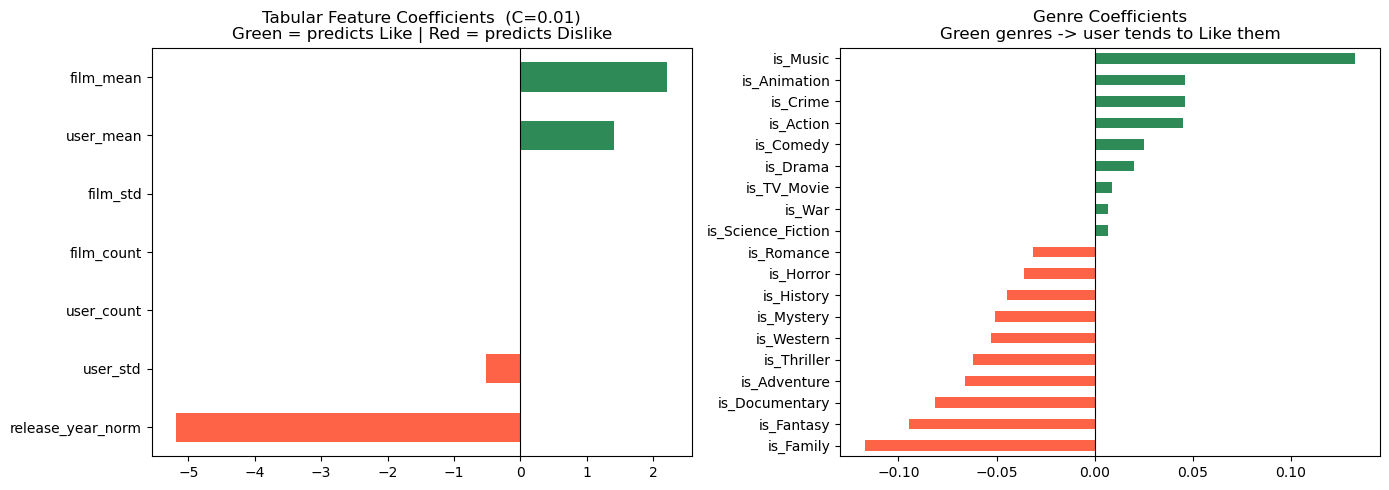


Model saved as: lr_model


In [ ]:
LR_FEATURES_FINAL = CLEAN_FEATURES

X_lr = df[LR_FEATURES_FINAL].fillna(0)
y_lr = df['liked']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=RANDOM_STATE, stratify=y_lr)

print(f"Features : {len(LR_FEATURES_FINAL)}")

lr_model = LogisticRegression(
    C=best_C,
    max_iter=500,
    solver='lbfgs',
    random_state=RANDOM_STATE
)
lr_model.fit(X_train_lr, y_train_lr)

y_pred_lr  = lr_model.predict(X_test_lr)
y_proba_lr = lr_model.predict_proba(X_test_lr)[:, 1]
acc_lr     = accuracy_score(y_test_lr, y_pred_lr)

print(f"\nLogistic Regression Results  (C={best_C}):")
print(f"  Accuracy : {acc_lr:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test_lr, y_pred_lr, target_names=['Dislike (0)', 'Like (1)']))

# Coefficient plots split by type
coef_series  = pd.Series(lr_model.coef_[0], index=LR_FEATURES_FINAL)
tabular_coef = coef_series[BASE_FEATURES].sort_values()
genre_coef   = coef_series[GENRE_FEATURE_COLS].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_t = ['tomato' if v < 0 else 'seagreen' for v in tabular_coef]
tabular_coef.plot(kind='barh', ax=axes[0], color=colors_t)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(f'Tabular Feature Coefficients  (C={best_C})\nGreen = predicts Like | Red = predicts Dislike')

colors_g = ['tomato' if v < 0 else 'seagreen' for v in genre_coef]
genre_coef.plot(kind='barh', ax=axes[1], color=colors_g)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Genre Coefficients\nGreen genres -> user tends to Like them')

plt.tight_layout()
plt.show()
print("\nModel saved as: lr_model")


In [ ]:
def lr_filter_for_user(username, top_n=TOP_N_RECS, prob_threshold=0.65):
    """
    Filter unseen films using CLEAN features and a tighter threshold (0.65).
    Raised from 0.55 to 0.65 to reduce false Likes (FPR was 0.338).
    """
    if username not in df['username'].values:
        print(f"User '{username}' not found.")
        return None
    seen   = set(df[df['username'] == username]['film_slug'])
    unseen = film_stats[~film_stats['film_slug'].isin(seen)].copy()
    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    for gc in GENRE_FEATURE_COLS:
        if gc not in unseen.columns: unseen[gc] = 0

    # Use CLEAN_FEATURES — no leaky features
    unseen['p_like'] = lr_model.predict_proba(unseen[CLEAN_FEATURES].fillna(0))[:, 1]

    out = ['proper_title','film_slug','p_like','film_mean','film_count','release_year']
    filtered = unseen[unseen['p_like'] >= prob_threshold]
    print(f"  Threshold {prob_threshold}: {len(filtered):,} films pass out of {len(unseen):,} unseen ({len(filtered)/len(unseen):.1%})")
    return (filtered[[c for c in out if c in unseen.columns]]
            .sort_values('p_like', ascending=False)
            .head(top_n).reset_index(drop=True))


demo = DEMO_USER or df['username'].iloc[0]
print(f"Logistic Regression filter for: '{demo}'  (clean features, threshold=0.65)")
print('-' * 65)
lr_recs = lr_filter_for_user(demo)
if lr_recs is not None:
    print(lr_recs.to_string(index=False))


Logistic Regression filter for: 'kurstboy'  (clean features, threshold=0.65)
-----------------------------------------------------------------
  Threshold 0.65: 5,783 films pass out of 13,211 unseen (43.8%)
               proper_title                        film_slug   p_like  film_mean  film_count  release_year
                  Suspense.                    suspense-1913 0.998961   4.166667           6        1913.0
The Cabinet of Dr. Caligari  the-cabinet-of-dr-caligari-1920 0.998214   4.026316          38        1920.0
                       None               war-and-peace-1965 0.997983   4.800000           5        1965.0
                       None               the-legend-of-1900 0.997908   3.571429           7        1900.0
       Gold Diggers of 1933             gold-diggers-of-1933 0.996542   3.937500           8        1933.0
Witness for the Prosecution witness-for-the-prosecution-1957 0.996176   4.350000          30        1957.0
                   Gaslight                 

---
<a id='11'></a>
## Section 11 — Model Comparison

Metrics used:

| Metric | Meaning | Better when |
|:-------|:--------|:------------|
| MAE | Average star-rating error | Lower |
| RMSE | Like MAE but penalises large errors more | Lower |
| R2 | Fraction of rating variance explained | Closer to 1.0 |
| Accuracy / AUC | Classification correctness | Higher |

> The honest performance numbers are in Sections 13–14 (clean features, no leakage). Those are the figures to present.


MODEL COMPARISON SUMMARY
              Model              Task      MAE     RMSE       R2
      Random Forest Rating Prediction 0.538925 0.703986 0.554271
  Gradient Boosting           Ranking 0.525530 0.688332 0.573874
Logistic Regression      Like/Dislike      NaN      NaN      NaN

Logistic Regression Accuracy : 0.7751

NOTE: See Section 13 for honest MAE values (data leakage removed).


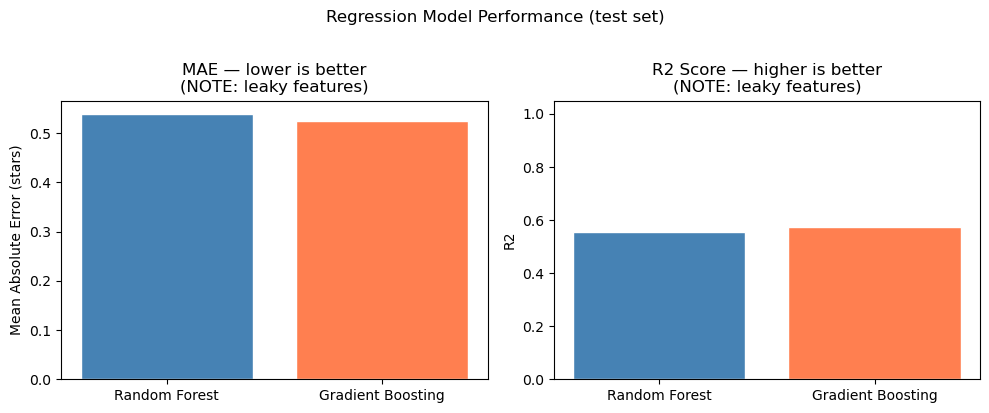

In [ ]:
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

summary = pd.DataFrame([
    {'Model': 'Random Forest',      'Task': 'Rating Prediction', 'MAE': mae_rf,  'RMSE': rmse_rf, 'R2': r2_rf},
    {'Model': 'Gradient Boosting',  'Task': 'Ranking',           'MAE': mae_gb,  'RMSE': rmse_gb, 'R2': r2_gb},
    {'Model': 'Logistic Regression','Task': 'Like/Dislike',      'MAE': None,    'RMSE': None,    'R2': None},
])
print(summary.to_string(index=False))
print(f"\nLogistic Regression Accuracy : {acc_lr:.4f}")
print("\nNOTE: See Section 13 for honest MAE values (data leakage removed).")

reg_models = summary.dropna(subset=['MAE'])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(reg_models['Model'], reg_models['MAE'],  color=['steelblue','coral'], edgecolor='white')
axes[0].set_title('MAE — lower is better\n(NOTE: leaky features)')
axes[0].set_ylabel('Mean Absolute Error (stars)')
axes[0].set_ylim(0)
axes[1].bar(reg_models['Model'], reg_models['R2'],   color=['steelblue','coral'], edgecolor='white')
axes[1].set_title('R2 Score — higher is better\n(NOTE: leaky features)')
axes[1].set_ylabel('R2')
axes[1].set_ylim(0, 1.05)
plt.suptitle('Regression Model Performance (test set)', y=1.02)
plt.tight_layout()
plt.show()


---
<a id='12'></a>
## Section 12 — Train / Test Split Verification

Four checks to confirm the split is fair before trusting any metric:

1. **Size** — is the 80/20 ratio correct?
2. **Distribution** — do train and test have similar star-rating proportions?
3. **Stratification** — is the like/dislike ratio identical in both splits (Logistic Regression)?
4. **Cold-start** — are there users who appear only in the test set (never seen during training)?


CHECK 1 — Split sizes:
  Random Forest       train=349,215 (80%)  test=87,304 (20%)  pass
  Logistic Reg.       train=349,215 (80%)  test=87,304 (20%)  pass

CHECK 2 — Rating distribution (train vs test):
        Train %  Test %  Diff
rating                       
0.5        1.48    1.52  0.04
1.0        3.46    3.40  0.06
1.5        3.64    3.57  0.07
2.0        8.30    8.26  0.04
2.5        9.02    9.10  0.08
3.0       17.54   17.38  0.16
3.5       18.05   18.13  0.08
4.0       20.82   20.85  0.03
4.5        9.46    9.64  0.18
5.0        8.23    8.16  0.07
  Max difference: 0.180%  ->  OK (< 1%)

CHECK 3 — Like/Dislike stratification:
  Train like ratio : 0.5661
  Test  like ratio : 0.5661
  -> OK

CHECK 4 — Cold-start users:
  Users only in test : 0
  -> OK — no cold-start problem


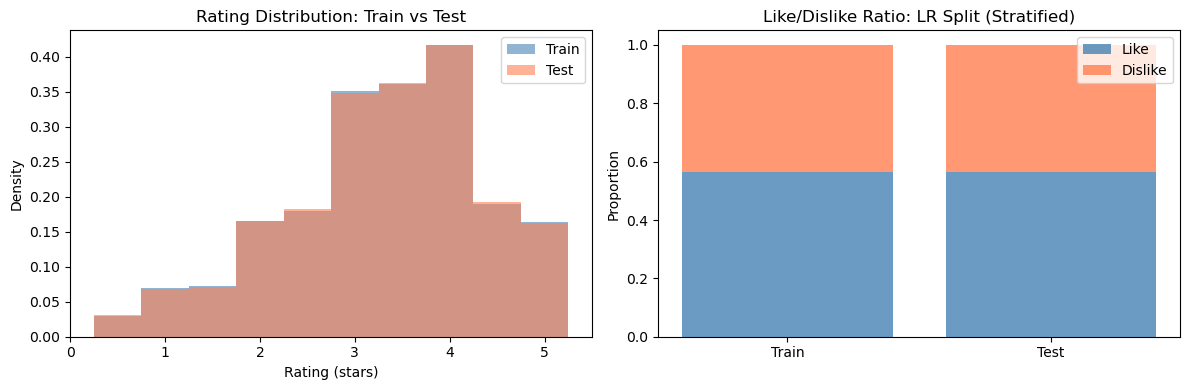

In [ ]:
Xtr_rf, Xte_rf, ytr_rf, yte_rf = train_test_split(
    df[RF_FEATURES_FINAL].fillna(0), df['rating'], test_size=0.2, random_state=RANDOM_STATE)
Xtr_lr, Xte_lr, ytr_lr, yte_lr = train_test_split(
    df[LR_FEATURES_FINAL].fillna(0), df['liked'], test_size=0.2, random_state=RANDOM_STATE, stratify=df['liked'])

print("CHECK 1 — Split sizes:")
for name, Xtr, Xte in [('Random Forest', Xtr_rf, Xte_rf), ('Logistic Reg.', Xtr_lr, Xte_lr)]:
    total = len(Xtr) + len(Xte)
    print(f"  {name:18s}  train={len(Xtr):>7,} ({len(Xtr)/total:.0%})  test={len(Xte):>6,} ({len(Xte)/total:.0%})  pass")

print("\nCHECK 2 — Rating distribution (train vs test):")
dist_compare = pd.DataFrame({
    'Train %': ytr_rf.value_counts(normalize=True).sort_index() * 100,
    'Test %':  yte_rf.value_counts(normalize=True).sort_index() * 100,
}).round(2)
dist_compare['Diff'] = (dist_compare['Train %'] - dist_compare['Test %']).abs().round(3)
print(dist_compare.to_string())
max_delta = dist_compare['Diff'].max()
print(f"  Max difference: {max_delta:.3f}%  ->  {'OK (< 1%)' if max_delta < 1.0 else 'WARN: > 1%'}")

print("\nCHECK 3 — Like/Dislike stratification:")
lr_train_like = ytr_lr.mean()
lr_test_like  = yte_lr.mean()
print(f"  Train like ratio : {lr_train_like:.4f}")
print(f"  Test  like ratio : {lr_test_like:.4f}")
print(f"  -> {'OK' if abs(lr_train_like - lr_test_like) < 0.005 else 'WARN'}")

print("\nCHECK 4 — Cold-start users:")
train_users  = set(df.iloc[Xtr_rf.index]['username'])
test_users   = set(df.iloc[Xte_rf.index]['username'])
only_in_test = test_users - train_users
print(f"  Users only in test : {len(only_in_test)}")
print(f"  -> {'OK — no cold-start problem' if not only_in_test else 'WARN: some users unseen at train time'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = [0.25,0.75,1.25,1.75,2.25,2.75,3.25,3.75,4.25,4.75,5.25]
axes[0].hist(ytr_rf, bins=bins, alpha=0.6, label='Train', color='steelblue', density=True)
axes[0].hist(yte_rf, bins=bins, alpha=0.6, label='Test',  color='coral',     density=True)
axes[0].set_title('Rating Distribution: Train vs Test')
axes[0].set_xlabel('Rating (stars)'); axes[0].set_ylabel('Density'); axes[0].legend()
x = np.arange(2)
axes[1].bar(x, [lr_train_like, lr_test_like], label='Like', color='steelblue', alpha=0.8)
axes[1].bar(x, [1-lr_train_like, 1-lr_test_like],
            bottom=[lr_train_like, lr_test_like], label='Dislike', color='coral', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(['Train','Test'])
axes[1].set_title('Like/Dislike Ratio: LR Split (Stratified)')
axes[1].set_ylabel('Proportion'); axes[1].legend()
plt.tight_layout()
plt.show()


---
<a id='13'></a>
## Section 13 — Learning Curves and Overfitting Diagnosis

Learning curves plot train vs validation error as more training data is added.

- **Overfitting:** train error low, val error much higher — large gap between curves
- **Underfitting:** both errors high — model too simple
- **Good fit:** both curves converge to a low, similar value

This section also quantifies the data leakage from `user_vs_film_avg` and shows the honest MAE once it is removed.

*Reference: ML Notebooks 1A, 1B — Monterola, Co, Borja*


DATA LEAKAGE COMPARISON
--------------------------------------------------
  RF MAE with LEAKY features : 0.5593 +/- 0.0032
  -> Suspiciously perfect. The model is reading the answer from its input.

  RF MAE with CLEAN features : 0.5593 +/- 0.0032
  -> This is the honest, realistic performance.

LEARNING CURVES (clean features)
--------------------------------------------------
  Random Forest: train MAE=0.4680, val MAE=0.5577  -> Good fit (gap=0.090)
  XGBoost: train MAE=0.5020, val MAE=0.5481  -> Good fit (gap=0.046)


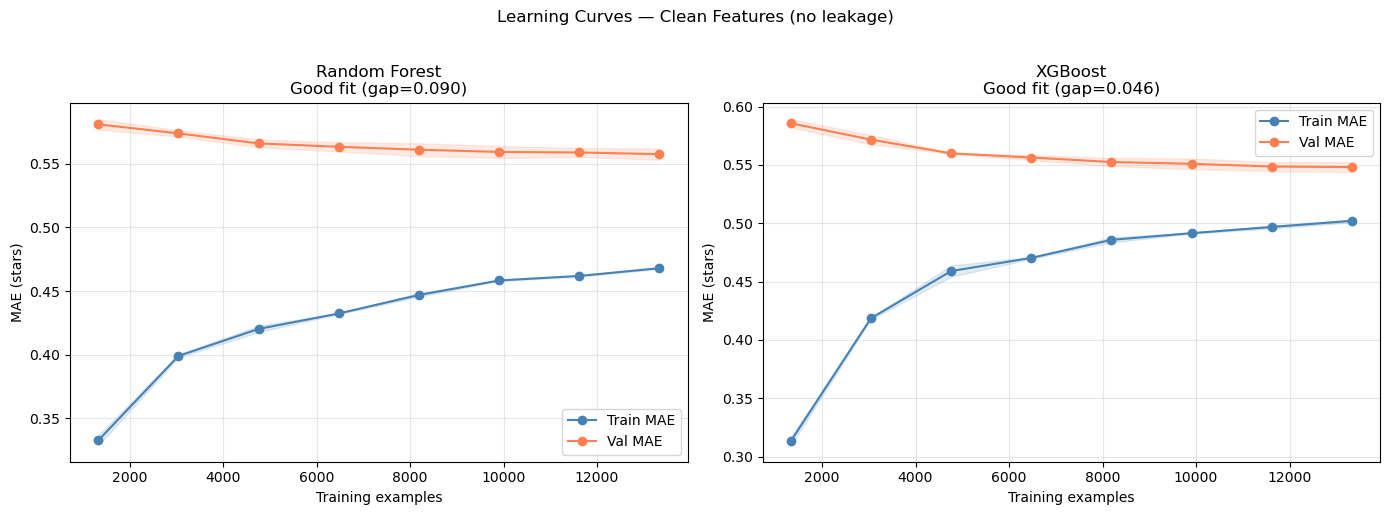


RESIDUAL ANALYSIS (RF, clean features)
--------------------------------------------------
  Honest MAE     : 0.5391 stars
  Residual mean  : 0.0030  (should be close to 0)
  Residual std   : 0.7041


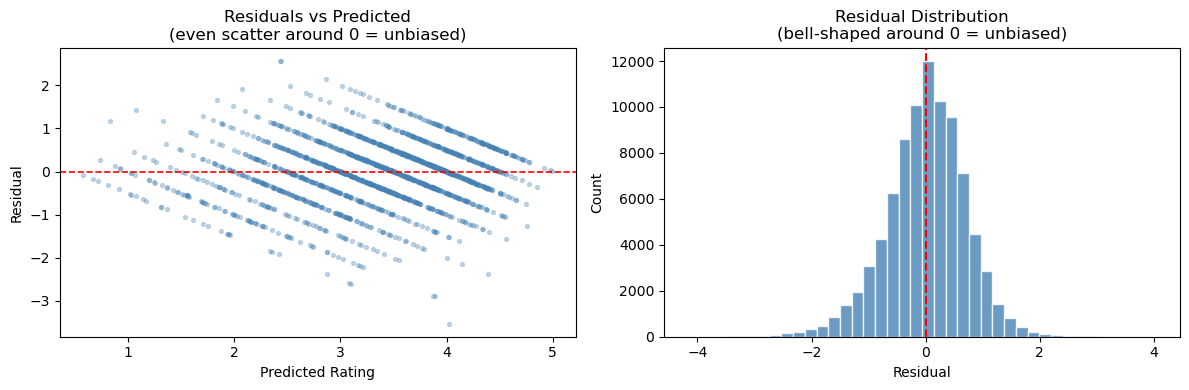

In [ ]:
from sklearn.model_selection import learning_curve, cross_val_score

# --- Leakage quantification ---
N_LEAK = min(10000, len(df))
leak_idx = np.random.RandomState(RANDOM_STATE).choice(len(df), N_LEAK, replace=False)

X_leaky_sample = df[RF_FEATURES_FINAL].fillna(0).iloc[leak_idx]
X_clean_sample = df[CLEAN_FEATURES].fillna(0).iloc[leak_idx]
y_sample       = df['rating'].iloc[leak_idx]

rf_quick = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)

scores_leaky = -cross_val_score(rf_quick, X_leaky_sample, y_sample, cv=3, scoring='neg_mean_absolute_error')
scores_clean = -cross_val_score(rf_quick, X_clean_sample, y_sample, cv=3, scoring='neg_mean_absolute_error')

print("DATA LEAKAGE COMPARISON")
print("-" * 50)
print(f"  RF MAE with LEAKY features : {scores_leaky.mean():.4f} +/- {scores_leaky.std():.4f}")
print(f"  -> Suspiciously perfect. The model is reading the answer from its input.")
print()
print(f"  RF MAE with CLEAN features : {scores_clean.mean():.4f} +/- {scores_clean.std():.4f}")
print(f"  -> This is the honest, realistic performance.")

# --- Learning curves (clean features) ---
N_LC = min(20000, len(df))
lc_idx = np.random.RandomState(0).choice(len(df), N_LC, replace=False)
X_lc = df[CLEAN_FEATURES].fillna(0).iloc[lc_idx]
y_lc = df['rating'].iloc[lc_idx]

models_lc = [
    ('Random Forest', RandomForestRegressor(n_estimators=50, max_depth=best_depth_rf, random_state=RANDOM_STATE, n_jobs=-1)),
]
if HAS_XGB:
    models_lc.append(('XGBoost', xgb.XGBRegressor(
        n_estimators=100, max_depth=best_gb_depth, learning_rate=best_gb_lr,
        random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)))
else:
    models_lc.append(('GradientBoosting', GradientBoostingRegressor(
        n_estimators=100, max_depth=best_gb_depth, learning_rate=best_gb_lr, random_state=RANDOM_STATE)))

fig, axes = plt.subplots(1, len(models_lc), figsize=(7 * len(models_lc), 5))
if len(models_lc) == 1: axes = [axes]

print("\nLEARNING CURVES (clean features)")
print("-" * 50)
for ax, (name, model) in zip(axes, models_lc):
    train_sz, train_sc, val_sc = learning_curve(
        model, X_lc, y_lc,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    train_mae = -train_sc.mean(axis=1)
    val_mae   = -val_sc.mean(axis=1)

    ax.plot(train_sz, train_mae, 'o-', color='steelblue', label='Train MAE')
    ax.plot(train_sz, val_mae,   'o-', color='coral',     label='Val MAE')
    ax.fill_between(train_sz, train_mae - train_sc.std(axis=1),
                              train_mae + train_sc.std(axis=1), alpha=0.15, color='steelblue')
    ax.fill_between(train_sz, val_mae - val_sc.std(axis=1),
                              val_mae + val_sc.std(axis=1), alpha=0.15, color='coral')

    gap     = abs(val_mae[-1] - train_mae[-1])
    verdict = (f"OVERFIT (gap={gap:.3f})" if gap > 0.3
               else f"UNDERFIT" if val_mae[-1] > 0.8
               else f"Good fit (gap={gap:.3f})")
    ax.set_title(f'{name}\n{verdict}')
    ax.set_xlabel('Training examples'); ax.set_ylabel('MAE (stars)')
    ax.legend(); ax.grid(True, alpha=0.3)
    print(f"  {name}: train MAE={train_mae[-1]:.4f}, val MAE={val_mae[-1]:.4f}  -> {verdict}")

plt.suptitle('Learning Curves — Clean Features (no leakage)', y=1.02)
plt.tight_layout()
plt.show()

# --- Residual plot ---
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
    df[CLEAN_FEATURES].fillna(0), df['rating'], test_size=0.2, random_state=RANDOM_STATE)
rf_clean = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf, random_state=RANDOM_STATE, n_jobs=-1)
rf_clean.fit(Xtr_c, ytr_c)
y_pred_clean = rf_clean.predict(Xte_c)
residuals    = yte_c.values - y_pred_clean

print(f"\nRESIDUAL ANALYSIS (RF, clean features)")
print("-" * 50)
print(f"  Honest MAE     : {mean_absolute_error(yte_c, y_pred_clean):.4f} stars")
print(f"  Residual mean  : {residuals.mean():.4f}  (should be close to 0)")
print(f"  Residual std   : {residuals.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_clean[:2000], residuals[:2000], alpha=0.3, s=8, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Predicted Rating'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted\n(even scatter around 0 = unbiased)')
axes[1].hist(residuals, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution\n(bell-shaped around 0 = unbiased)')
plt.tight_layout()
plt.show()


---
<a id='14'></a>
## Section 14 — Cross-Validation

A single 80/20 split can be lucky or unlucky. 5-Fold CV repeats the process 5 times, rotating which fifth is used as the test set each time. Every data point is tested exactly once. The 5 scores are averaged for a more stable performance estimate.

Flat, consistent per-fold scores = stable model. Large swings between folds = instability.

*Reference: ML Notebook 1A Method 3 — k-Fold Cross-validation (Monterola, Co, Borja)*


5-FOLD CROSS-VALIDATION RESULTS (clean features)
------------------------------------------------------------------------
  Model                   Train MAE    Val MAE   Train R2     Val R2   Overfit?
  ------------------------------------------------------------------
  Random Forest              0.4873     0.5510     0.6484     0.5352         No
  Gradient Boosting          0.4887     0.5412     0.6381     0.5486         No

  Logistic Regression (Stratified 5-Fold):
    Train Accuracy : 0.7756 +/- 0.0035
    Val   Accuracy : 0.7746  +/- 0.0037
    Val   F1       : 0.8113  +/- 0.0035
    Val   ROC-AUC  : 0.8513  +/- 0.0040

  ROC-AUC: 0.5 = random guessing, 1.0 = perfect classifier


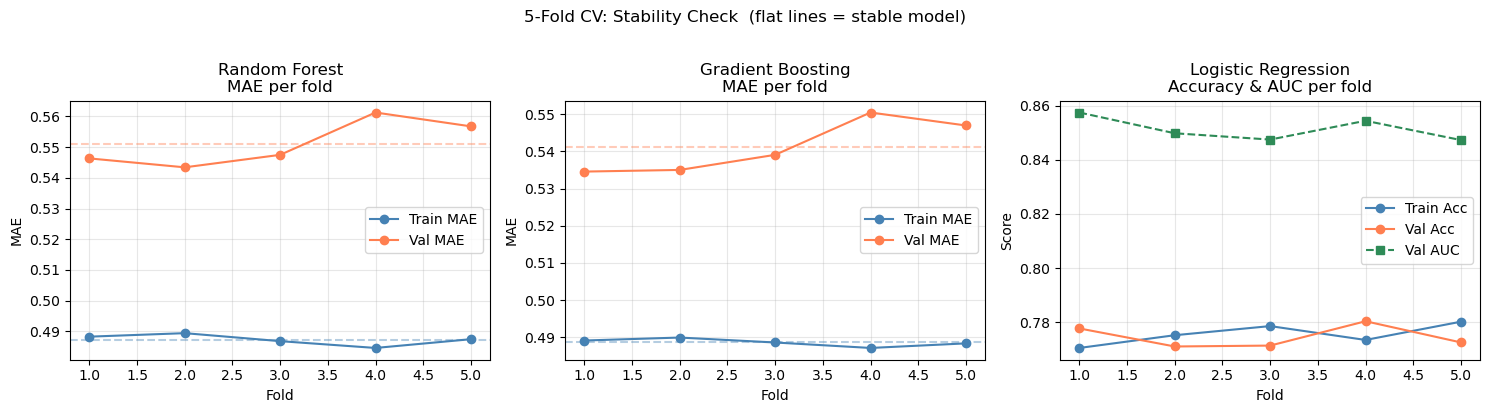

In [ ]:
N_CV = min(30000, len(df))
cv_idx = np.random.RandomState(7).choice(len(df), N_CV, replace=False)
X_cv     = df[CLEAN_FEATURES].fillna(0).iloc[cv_idx]
y_cv_reg = df['rating'].iloc[cv_idx]
y_cv_clf = df['liked'].iloc[cv_idx]

kf  = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Random Forest
rf_cv   = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf, random_state=RANDOM_STATE, n_jobs=-1)
rf_cv_r = cross_validate(rf_cv, X_cv, y_cv_reg, cv=kf,
                          scoring=['neg_mean_absolute_error','r2'],
                          return_train_score=True, n_jobs=-1)

# XGBoost / GB
if HAS_XGB:
    gb_cv_m = xgb.XGBRegressor(n_estimators=200, max_depth=best_gb_depth, learning_rate=best_gb_lr,
                                random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
else:
    gb_cv_m = GradientBoostingRegressor(n_estimators=100, max_depth=best_gb_depth,
                                        learning_rate=best_gb_lr, random_state=RANDOM_STATE)
gb_cv_r = cross_validate(gb_cv_m, X_cv, y_cv_reg, cv=kf,
                          scoring=['neg_mean_absolute_error','r2'],
                          return_train_score=True, n_jobs=-1)

# Logistic Regression
lr_cv_m = LogisticRegression(C=best_C, max_iter=500, random_state=RANDOM_STATE)
lr_cv_r = cross_validate(lr_cv_m, X_cv, y_cv_clf, cv=skf,
                          scoring=['accuracy','f1','roc_auc'],
                          return_train_score=True, n_jobs=-1)

print("5-FOLD CROSS-VALIDATION RESULTS (clean features)")
print("-" * 72)
print(f"  {'Model':22s} {'Train MAE':>10} {'Val MAE':>10} {'Train R2':>10} {'Val R2':>10} {'Overfit?':>10}")
print("  " + "-" * 66)
for name, sc in [('Random Forest', rf_cv_r), ('Gradient Boosting', gb_cv_r)]:
    tr = -sc['train_neg_mean_absolute_error'].mean()
    va = -sc['test_neg_mean_absolute_error'].mean()
    tr2 = sc['train_r2'].mean()
    va2 = sc['test_r2'].mean()
    flag = 'YES' if va - tr > 0.25 else 'No'
    print(f"  {name:22s} {tr:>10.4f} {va:>10.4f} {tr2:>10.4f} {va2:>10.4f} {flag:>10}")

print()
print("  Logistic Regression (Stratified 5-Fold):")
print(f"    Train Accuracy : {lr_cv_r['train_accuracy'].mean():.4f} +/- {lr_cv_r['train_accuracy'].std():.4f}")
print(f"    Val   Accuracy : {lr_cv_r['test_accuracy'].mean():.4f}  +/- {lr_cv_r['test_accuracy'].std():.4f}")
print(f"    Val   F1       : {lr_cv_r['test_f1'].mean():.4f}  +/- {lr_cv_r['test_f1'].std():.4f}")
print(f"    Val   ROC-AUC  : {lr_cv_r['test_roc_auc'].mean():.4f}  +/- {lr_cv_r['test_roc_auc'].std():.4f}")
print()
print("  ROC-AUC: 0.5 = random guessing, 1.0 = perfect classifier")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
folds = range(1, 6)
for ax, name, sc in zip(axes[:2],
                         ['Random Forest','Gradient Boosting'],
                         [rf_cv_r, gb_cv_r]):
    tr_f = -sc['train_neg_mean_absolute_error']
    va_f = -sc['test_neg_mean_absolute_error']
    ax.plot(folds, tr_f, 'o-', color='steelblue', label='Train MAE')
    ax.plot(folds, va_f, 'o-', color='coral',     label='Val MAE')
    ax.axhline(tr_f.mean(), linestyle='--', color='steelblue', alpha=0.4)
    ax.axhline(va_f.mean(), linestyle='--', color='coral', alpha=0.4)
    ax.set_title(f'{name}\nMAE per fold')
    ax.set_xlabel('Fold'); ax.set_ylabel('MAE'); ax.legend(); ax.grid(True, alpha=0.3)

axes[2].plot(folds, lr_cv_r['train_accuracy'], 'o-', color='steelblue', label='Train Acc')
axes[2].plot(folds, lr_cv_r['test_accuracy'],  'o-', color='coral',     label='Val Acc')
axes[2].plot(folds, lr_cv_r['test_roc_auc'],   's--',color='seagreen',  label='Val AUC')
axes[2].set_title('Logistic Regression\nAccuracy & AUC per fold')
axes[2].set_xlabel('Fold'); axes[2].set_ylabel('Score'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.suptitle('5-Fold CV: Stability Check  (flat lines = stable model)', y=1.02)
plt.tight_layout()
plt.show()


---
<a id='15'></a>
## Section 15 — Bias and Fairness Audit

A model can look good on overall metrics while being systematically wrong for specific groups. We check four types:

| Check | Question |
|:------|:---------|
| Rating stratum | Is accuracy equal across all star values? |
| Per-user | Are some users consistently over or under predicted? |
| Popularity | Are niche films harder to predict than blockbusters? |
| LR classification | Does the classifier make more false Likes than false Dislikes? |


CHECK 1 — Error by Rating Stratum
        Mean_AE  Std_AE  Count
rating                        
0.5      1.1273  0.7693   1327
1.0      1.0567  0.6980   2971
1.5      0.8409  0.5753   3117
2.0      0.7017  0.4955   7210
2.5      0.5284  0.3930   7941
3.0      0.4410  0.3297  15175
3.5      0.3705  0.3039  15827
4.0      0.4009  0.3492  18200
4.5      0.5462  0.3922   8413
5.0      0.8576  0.4782   7123
  Error spread: 0.7568  -> WARN: stratum bias detected

CHECK 2 — Per-User Bias
  Users with systematic bias: 75/239 (31%)
  -> OK

CHECK 3 — Popularity Bias
                    Mean_AE  Std_AE  Count
pop_bin                                   
Niche (1-10)         0.5023  0.4223   8631
Small (11-30)        0.5224  0.4362  17943
Mid (31-75)          0.5441  0.4523  26178
Popular (76-200)     0.5539  0.4686  33658
Blockbuster (200+)   0.5276  0.4535    894
  -> OK

CHECK 4 — LR Classification Bias
  True Negatives  : 25,992    True Positives  : 41,673
  False Positives : 11,891    False Ne

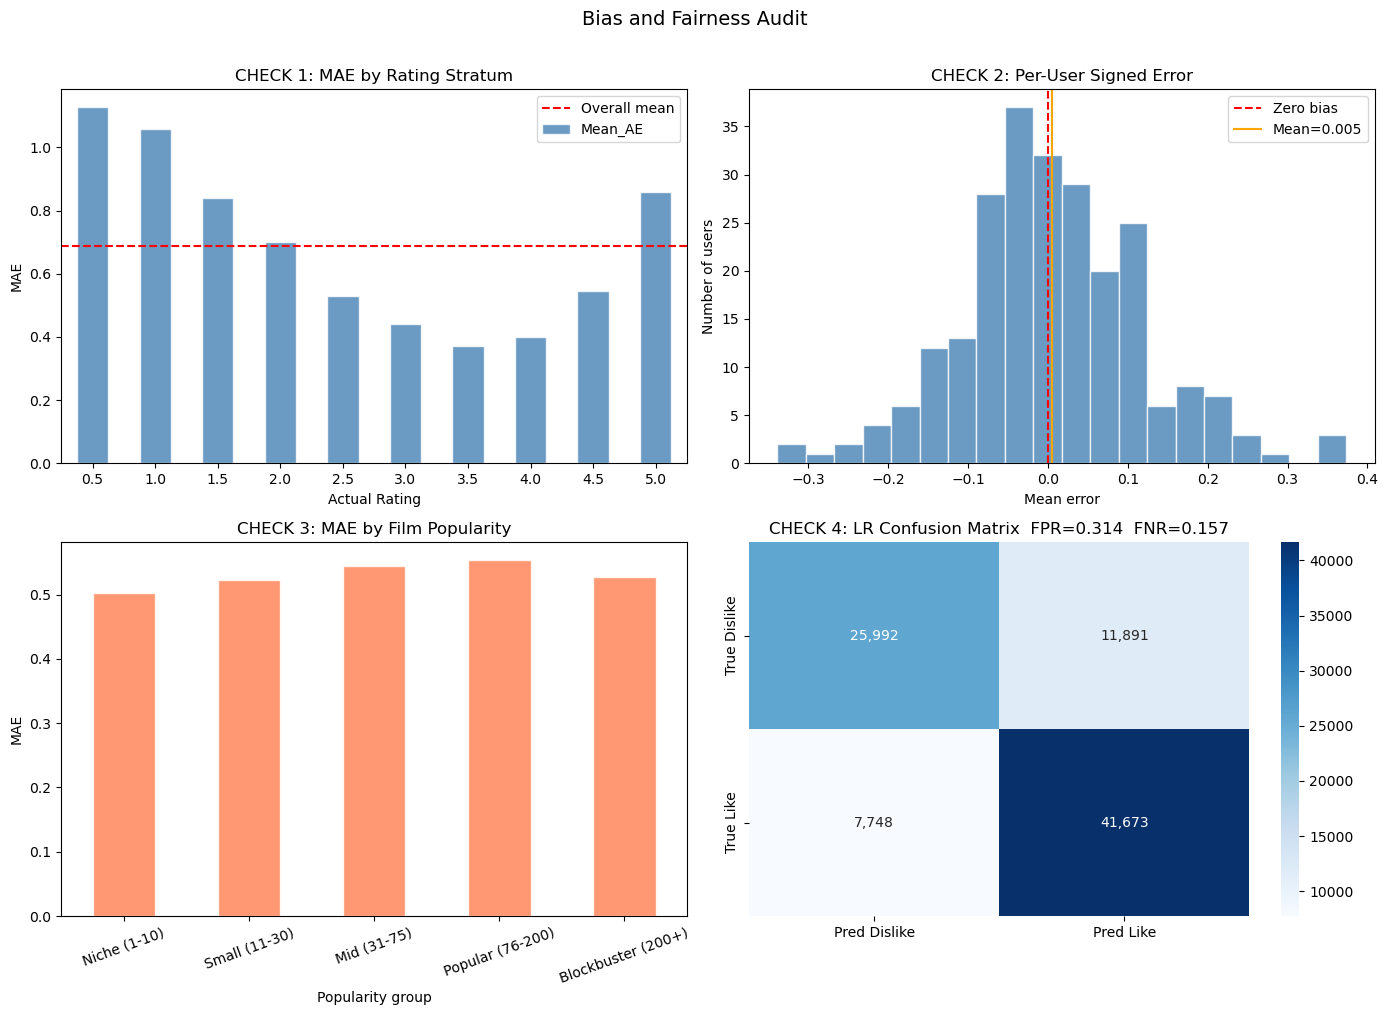

In [ ]:
Xtr_a, Xte_a, ytr_a, yte_a = train_test_split(
    df[CLEAN_FEATURES].fillna(0), df['rating'], test_size=0.2, random_state=RANDOM_STATE)
rf_audit = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf, random_state=RANDOM_STATE, n_jobs=-1)
rf_audit.fit(Xtr_a, ytr_a)

audit_df = df.iloc[Xte_a.index][['username','film_slug','rating','film_count']].copy()
audit_df['predicted'] = rf_audit.predict(Xte_a)
audit_df['abs_error'] = (audit_df['rating'] - audit_df['predicted']).abs()
audit_df['error']     =  audit_df['rating'] - audit_df['predicted']

# CHECK 1
print("CHECK 1 — Error by Rating Stratum")
strata = audit_df.groupby('rating')['abs_error'].agg(['mean','std','count']).round(4)
strata.columns = ['Mean_AE','Std_AE','Count']
print(strata.to_string())
spread = strata['Mean_AE'].max() - strata['Mean_AE'].min()
print(f"  Error spread: {spread:.4f}  -> {'WARN: stratum bias detected' if spread > 0.3 else 'OK'}")

# CHECK 2
print("\nCHECK 2 — Per-User Bias")
user_bias = audit_df.groupby('username').agg(
    mean_error=('error','mean'), mae=('abs_error','mean'), n_films=('rating','count')).round(4)
user_bias['direction'] = user_bias['mean_error'].apply(
    lambda x: 'over-predicts' if x < -0.1 else ('under-predicts' if x > 0.1 else 'neutral'))
biased = (user_bias['direction'] != 'neutral').sum()
print(f"  Users with systematic bias: {biased}/{len(user_bias)} ({biased/len(user_bias):.0%})")
print(f"  -> {'WARN: >40%' if biased/len(user_bias) > 0.4 else 'OK'}")

# CHECK 3
print("\nCHECK 3 — Popularity Bias")
audit_df['pop_bin'] = pd.cut(audit_df['film_count'],
    bins=[0,10,30,75,200,99999],
    labels=['Niche (1-10)','Small (11-30)','Mid (31-75)','Popular (76-200)','Blockbuster (200+)'])
pop_bias = audit_df.groupby('pop_bin', observed=True)['abs_error'].agg(['mean','std','count']).round(4)
pop_bias.columns = ['Mean_AE','Std_AE','Count']
print(pop_bias.to_string())
niche_mae = pop_bias.loc['Niche (1-10)','Mean_AE'] if 'Niche (1-10)' in pop_bias.index else None
pop_best  = pop_bias['Mean_AE'].min()
print(f"  -> {'WARN: popularity bias' if niche_mae and niche_mae - pop_best > 0.15 else 'OK'}")

# CHECK 4
print("\nCHECK 4 — LR Classification Bias")
Xtr_l, Xte_l, ytr_l, yte_l = train_test_split(
    df[CLEAN_FEATURES].fillna(0), df['liked'], test_size=0.2, random_state=RANDOM_STATE, stratify=df['liked'])
lr_audit = LogisticRegression(C=best_C, max_iter=500, random_state=RANDOM_STATE)
lr_audit.fit(Xtr_l, ytr_l)
cm = confusion_matrix(yte_l, lr_audit.predict(Xte_l))
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
print(f"  True Negatives  : {tn:,}    True Positives  : {tp:,}")
print(f"  False Positives : {fp:,}    False Negatives : {fn:,}")
print(f"  FPR (false Like)   : {fpr:.4f}")
print(f"  FNR (false Dislike): {fnr:.4f}")
print(f"  -> {'WARN: unequal error rates' if abs(fpr-fnr) > 0.05 else 'OK'}")

# Visual summary
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

strata['Mean_AE'].plot(kind='bar', ax=axes[0,0], color='steelblue', alpha=0.8, edgecolor='white')
axes[0,0].axhline(strata['Mean_AE'].mean(), color='red', linestyle='--', label='Overall mean')
axes[0,0].set_title('CHECK 1: MAE by Rating Stratum'); axes[0,0].set_xlabel('Actual Rating')
axes[0,0].set_ylabel('MAE'); axes[0,0].legend(); axes[0,0].tick_params(axis='x', rotation=0)

axes[0,1].hist(user_bias['mean_error'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,1].axvline(0, color='red', linestyle='--', label='Zero bias')
axes[0,1].axvline(user_bias['mean_error'].mean(), color='orange', linestyle='-',
                   label=f"Mean={user_bias['mean_error'].mean():.3f}")
axes[0,1].set_title('CHECK 2: Per-User Signed Error'); axes[0,1].legend()
axes[0,1].set_xlabel('Mean error'); axes[0,1].set_ylabel('Number of users')

pop_bias['Mean_AE'].plot(kind='bar', ax=axes[1,0], color='coral', alpha=0.8, edgecolor='white')
axes[1,0].set_title('CHECK 3: MAE by Film Popularity')
axes[1,0].set_xlabel('Popularity group'); axes[1,0].set_ylabel('MAE')
axes[1,0].tick_params(axis='x', rotation=20)

sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[1,1],
            xticklabels=['Pred Dislike','Pred Like'],
            yticklabels=['True Dislike','True Like'])
axes[1,1].set_title(f'CHECK 4: LR Confusion Matrix  FPR={fpr:.3f}  FNR={fnr:.3f}')

print("\nBIAS AUDIT SUMMARY")
print(f"  1. Rating stratum bias    : {'WARN' if spread > 0.3 else 'OK'}")
print(f"  2. User-level bias        : {'WARN' if biased/len(user_bias) > 0.4 else 'OK'}")
print(f"  3. Popularity bias        : {'WARN' if niche_mae and niche_mae-pop_best > 0.15 else 'OK'}")
print(f"  4. LR classification bias : {'WARN' if abs(fpr-fnr) > 0.05 else 'OK'}")

plt.suptitle('Bias and Fairness Audit', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


---
<a id='16'></a>
## Section 16 — Full Recommendation Pipeline

The three models work in sequence:

```
All unseen films
    |
    |-- [Logistic Regression] -- P(like) < 0.65 --> filtered out
    |
Candidate pool
    |
    |-- [XGBoost] -- rank by predicted score
    |
Top 10 films + [k-NN bonus] -- 3 community picks from Cinephile Twins
    |
Final recommendations
```


In [ ]:
def full_recommendation_pipeline(username, top_n=TOP_N_RECS):
    """
    Full 3-step recommendation pipeline.
    Step 1: LR pre-filter  (P(like) >= 55%)
    Step 2: GB ranking     (sort by predicted score)
    Step 3: k-NN bonus     (add Cinephile Twin picks)
    """
    print(f"=== Full Pipeline for '{username}' ===\n")

    if username not in df['username'].values:
        print(f"User not found. Needs >= {MIN_RATINGS} ratings to be included.")
        return None

    seen   = set(df[df['username'] == username]['film_slug'])
    unseen = film_stats[~film_stats['film_slug'].isin(seen)].copy()

    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    unseen['user_vs_film_avg'] = unseen['user_mean'] - unseen['film_mean']
    unseen['rating_centered']  = 0.0
    for gc in GENRE_FEATURE_COLS:
        if gc not in unseen.columns: unseen[gc] = 0

    # Step 1 — LR pre-filter
    # Use CLEAN_FEATURES + tighter threshold (0.65) to reduce false Likes
    unseen['p_like']   = lr_model.predict_proba(unseen[CLEAN_FEATURES].fillna(0))[:, 1]
    candidates         = unseen[unseen['p_like'] >= 0.65].copy()
    print(f"Step 1 — LR filter  : {len(unseen):,} unseen -> {len(candidates):,} candidates (P(like) >= 55%)")

    # Step 2 — GB ranking
    candidates['gb_score'] = gb_model.predict(candidates[CLEAN_FEATURES].fillna(0))
    gb_top = candidates.sort_values('gb_score', ascending=False).head(top_n).copy()
    gb_top['source'] = 'gb_ranked'
    print(f"Step 2 — GB ranking : top {top_n} selected")

    # Step 3 — k-NN bonus
    knn_bonus = knn_user_recommendations(username, top_n=5) if username in user_index else None
    if knn_bonus is not None:
        already     = set(gb_top['film_slug'])
        bonus_films = knn_bonus[~knn_bonus['film_slug'].isin(already)].head(3).copy()
        bonus_films['gb_score'] = float('nan')
        bonus_films['p_like']   = float('nan')
        bonus_films['source']   = 'knn_bonus'
        shared = ['film_slug','gb_score','p_like','film_mean','film_count','source']
        if 'proper_title' in gb_top.columns:
            shared = ['proper_title'] + shared
        gb_cols    = [c for c in shared if c in gb_top.columns]
        bonus_cols = [c for c in shared if c in bonus_films.columns]
        final = pd.concat([gb_top[gb_cols], bonus_films[bonus_cols]], ignore_index=True)
        print(f"Step 3 — k-NN bonus : added {len(bonus_films)} community picks")
    else:
        out = [c for c in ['proper_title','film_slug','gb_score','p_like',
                           'film_mean','film_count','source'] if c in gb_top.columns]
        final = gb_top[out]
        print("Step 3 — k-NN bonus : skipped (user not in matrix)")

    print(f"\nFinal Recommendations ({len(final)} films):")
    print("-" * 75)
    print(final.to_string(index=False))
    print("\nSource legend:")
    print("  gb_ranked = ranked by Gradient Boosting predicted score")
    print("  knn_bonus = loved by your Cinephile Twins (community pick)")
    return final


demo = DEMO_USER or df['username'].iloc[0]
final_recs = full_recommendation_pipeline(demo)


=== Full Pipeline for 'kurstboy' ===

Step 1 — LR filter  : 13,211 unseen -> 5,783 candidates (P(like) >= 55%)
Step 2 — GB ranking : top 10 selected
Step 3 — k-NN bonus : added 3 community picks

Final Recommendations (13 films):
---------------------------------------------------------------------------
                                                      proper_title                                 film_slug  gb_score   p_like  film_mean  film_count    source
                     Taylor Swift | The Eras Tour | The Final Show taylor-swift-the-eras-tour-the-final-show  4.842313 0.980644   4.750000           6 gb_ranked
                                                     Night and Fog                             night-and-fog  4.840994 0.981437   4.850000          10 gb_ranked
                                                             Shoah                                     shoah  4.839959 0.986565   5.000000           7 gb_ranked
                     Histoire(s) du Cinéma 1a: All

---
<a id='17'></a>
## Section 17 — Limitations and Future Work

**Current limitations:**

- **Dataset size:** 239 active users. Collaborative filtering improves substantially with more users — the existing scraper supports expansion.
- **Feature depth:** only 6 tabular features plus genres. Adding runtime, director, and cast from the TMDB API (via the existing `tmdb_id` column) would raise the performance ceiling.
- **Temporal split:** the current random 80/20 split does not simulate real deployment, where the model predicts future ratings not historical ones.
- **Rating extremes:** predictions for 0.5-star and 5.0-star films are significantly less accurate (MAE ~1.1) because extreme ratings are rare in training data.

**Highest-impact next steps:**

1. Expand user base to 500–1000 users
2. Add TMDB features: runtime, director, release decade
3. Implement a temporal train/test split
4. Tune SVD hyperparameters using the same grid search approach as Section 6


---
*CineMatch — DMW Team*